In [5]:
# =========================================================
# CELL C0 — GPU check + dependencies
# =========================================================
import torch, sys
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

!pip install -q nibabel scipy huggingface_hub

Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [7]:
# =========================================================
# CELL C0.5 — Mount Google Drive (survives runtime restarts)
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/drive/MyDrive/kits23_backup/seg_cache", exist_ok=True)
os.makedirs("/content/drive/MyDrive/kits23_backup/seg_splits", exist_ok=True)
os.makedirs("/content/drive/MyDrive/kits23_backup/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/kits23_backup/results", exist_ok=True)
print("Drive ready.")

Mounted at /content/drive
Drive ready.


In [8]:
# =========================================================
# CELL C1 — Download KiTS23 (retry-safe, rate-limit friendly)
# =========================================================
import os, time
from pathlib import Path
from huggingface_hub import snapshot_download

os.environ["HF_HUB_DISABLE_XET"] = "1"

DATASET_ROOT = Path("/content/kits23_dataset")
DATASET_DIR  = DATASET_ROOT / "dataset"
DATASET_DIR.mkdir(parents=True, exist_ok=True)


def count_cases():
    return len(list(DATASET_DIR.glob("case_*/imaging.nii.gz")))


def count_segs():
    return len(list(DATASET_DIR.glob("case_*/segmentation.nii.gz")))


print(f"Cases before: {count_cases()} | segs: {count_segs()}")

MAX_RETRIES = 6
for attempt in range(1, MAX_RETRIES + 1):
    try:
        print(f"\n=== Attempt {attempt}/{MAX_RETRIES} ===")
        t0 = time.time()
        snapshot_download(
            repo_id="MedOtter/kits23",
            repo_type="dataset",
            local_dir=str(DATASET_ROOT),
            allow_patterns=[
                "dataset/case_*/imaging.nii.gz",
                "dataset/case_*/segmentation.nii.gz",
            ],
            max_workers=2,
        )
        print(f"Downloaded/verified in {(time.time() - t0) / 60:.1f} min")
        break
    except Exception as e:
        wait = min(2 ** attempt * 15, 300)
        print(f"Attempt {attempt} failed: {type(e).__name__}: {str(e)[:200]}")
        print(f"Cases so far: {count_cases()} | segs: {count_segs()}")
        if attempt < MAX_RETRIES:
            print(f"Sleeping {wait}s before retry...")
            time.sleep(wait)
        else:
            print("All retries exhausted. Re-run this cell to resume.")

n_img = count_cases()
n_seg = count_segs()
print(f"\nFinal: {n_img} imaging files, {n_seg} segmentation files")

if n_img >= 489 and n_seg >= 489:
    print("✅ Dataset complete.")
else:
    print(f"⚠️  Expected 489 each. Re-run this cell to resume.")

Cases before: 0 | segs: 0

=== Attempt 1/6 ===


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 978 files:   0%|          | 0/978 [00:00<?, ?it/s]

Downloaded/verified in 12.9 min

Final: 489 imaging files, 489 segmentation files
✅ Dataset complete.


In [4]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   87G  149G  37% /


In [13]:
# =========================================================
# Copy cache from Drive -> local /content/seg_cache
# =========================================================
import shutil, time
from pathlib import Path

DRIVE_CACHE = Path("/content/drive/MyDrive/kits23_backup/seg_cache")
LOCAL_CACHE = Path("/content/seg_cache")

# Sanity: confirm Drive cache has files
drive_n = len(list(DRIVE_CACHE.glob("*.npz")))
print(f"Drive cache files: {drive_n}")
if drive_n < 489:
    print("⚠️  Drive cache incomplete. Check the path:")
    print(f"  {DRIVE_CACHE}")
    print("  Contents:", [p.name for p in list(DRIVE_CACHE.iterdir())[:5]])
    raise SystemExit("Fix Drive path before copying.")

# Copy
LOCAL_CACHE.mkdir(parents=True, exist_ok=True)
local_n = len(list(LOCAL_CACHE.glob("*.npz")))
if local_n >= 489:
    print(f"Local cache already complete: {local_n}")
else:
    print(f"Copying {drive_n} files from Drive to /content...")
    t0 = time.time()
    for i, p in enumerate(DRIVE_CACHE.glob("*.npz")):
        shutil.copy2(p, LOCAL_CACHE / p.name)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{drive_n} ({time.time()-t0:.0f}s)")
    print(f"Copied {len(list(LOCAL_CACHE.glob('*.npz')))} files in {time.time()-t0:.0f}s")

# Verify
local_n = len(list(LOCAL_CACHE.glob("*.npz")))
print(f"\nLocal cache: {local_n} files")
print(f"Disk free:")
!df -h /content

Drive cache files: 489
Copying 489 files from Drive to /content...
  100/489 (108s)
  200/489 (222s)
  300/489 (350s)
  400/489 (476s)
Copied 489 files in 565s

Local cache: 489 files
Disk free:
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G  102G  135G  43% /


In [23]:
# =========================================================
# CELL C2 — Config (local cache for speed, Drive for outputs)
# =========================================================
import os, math, random, pickle, time
from pathlib import Path
from collections import defaultdict
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# ---------- Paths ----------
DATASET_DIR = Path("/content/kits23_dataset/dataset")

# FIX: cache local (fast reads), everything else on Drive (durable)
CACHE_DIR   = Path("/content/seg_cache")

DRIVE_ROOT  = Path("/content/drive/MyDrive/kits23_backup")
SPLIT_DIR   = DRIVE_ROOT / "seg_splits"
MODEL_DIR   = DRIVE_ROOT / "models"
RESULT_DIR  = DRIVE_ROOT / "results"

for d in [CACHE_DIR, SPLIT_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------- Classes ----------
NUM_CLASSES = 4
CLASS_NAMES = ["background", "kidney", "tumour", "cyst"]

# ---------- Preprocessing ----------
SLICE_SIZE = 192
SLICE_DEPTH = 3
HU_MIN, HU_MAX = -100, 300

# ---------- Training ----------
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 1e-3
SEED = 42
NUM_WORKERS = 4

CLASS_WEIGHTS = [0.1, 1.0, 3.0, 5.0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print(f"SLICE_SIZE={SLICE_SIZE} | BATCH_SIZE={BATCH_SIZE} | NUM_EPOCHS={NUM_EPOCHS}")
print(f"NUM_WORKERS={NUM_WORKERS} | CLASS_WEIGHTS={CLASS_WEIGHTS}")
print(f"CACHE_DIR:  {CACHE_DIR}")
print(f"SPLIT_DIR:  {SPLIT_DIR}")
print(f"MODEL_DIR:  {MODEL_DIR}")
print(f"RESULT_DIR: {RESULT_DIR}")

# Quick cache sanity check
n_cached = len(list(CACHE_DIR.glob("*.npz")))
print(f"\nCached .npz files: {n_cached}")
if n_cached < 489:
    print(f"⚠️  Expected 489. Re-run the Drive→local copy cell.")

Device: cuda
SLICE_SIZE=192 | BATCH_SIZE=32 | NUM_EPOCHS=40
NUM_WORKERS=4 | CLASS_WEIGHTS=[0.1, 1.0, 3.0, 5.0]
CACHE_DIR:  /content/seg_cache
SPLIT_DIR:  /content/drive/MyDrive/kits23_backup/seg_splits
MODEL_DIR:  /content/drive/MyDrive/kits23_backup/models
RESULT_DIR: /content/drive/MyDrive/kits23_backup/results

Cached .npz files: 489


In [24]:
# =========================================================
# CELL C3 — Preprocess NIfTI -> cached .npz at SLICE_SIZE
# Resumable: skips cases already cached.
# =========================================================
import nibabel as nib
from scipy.ndimage import zoom

case_dirs = sorted([p for p in DATASET_DIR.glob("case_*") if p.is_dir()])
print(f"Found {len(case_dirs)} case folders")


def preprocess_one(case_dir):
    cid = case_dir.name
    cache_path = CACHE_DIR / f"{cid}.npz"
    if cache_path.exists():
        return "skip"

    img = nib.load(str(case_dir / "imaging.nii.gz")).get_fdata().astype(np.float32)
    seg = nib.load(str(case_dir / "segmentation.nii.gz")).get_fdata().astype(np.float32)

    img = np.clip(img, HU_MIN, HU_MAX)
    img = (img - img.mean()) / (img.std() + 1e-8)

    H, W, D = img.shape
    zy, zx = SLICE_SIZE / H, SLICE_SIZE / W

    img = zoom(img, (zy, zx, 1.0), order=1)
    seg = zoom(seg, (zy, zx, 1.0), order=1)
    seg = np.rint(seg).astype(np.uint8)
    seg = np.clip(seg, 0, NUM_CLASSES - 1)

    img = np.transpose(img, (2, 0, 1)).astype(np.float16)
    seg = np.transpose(seg, (2, 0, 1))

    np.savez_compressed(cache_path, image=img, seg=seg)
    return "done"


already = len(list(CACHE_DIR.glob("*.npz")))
print(f"Already cached: {already}")
print(f"Caching remaining at {SLICE_SIZE}x{SLICE_SIZE} -> Drive...")

failed = []
for cd in tqdm(case_dirs, desc="Caching"):
    try:
        preprocess_one(cd)
    except Exception as e:
        failed.append((cd.name, str(e)))
        print(f"FAILED {cd.name}: {e}")

n_cached = len(list(CACHE_DIR.glob("*.npz")))
print(f"\nCached: {n_cached} files")
if failed:
    print(f"Failures: {len(failed)}")
    for name, err in failed[:10]:
        print(f"  {name}: {err[:120]}")

sample = next(CACHE_DIR.glob("*.npz"))
d = np.load(sample)
print(f"Sample {sample.name}: image {d['image'].shape} {d['image'].dtype} | "
      f"seg {d['seg'].shape} {d['seg'].dtype}")
print(f"Seg classes: {np.unique(d['seg']).tolist()}")

Found 489 case folders
Already cached: 489
Caching remaining at 192x192 -> Drive...


Caching:   0%|          | 0/489 [00:00<?, ?it/s]


Cached: 489 files
Sample case_00407.npz: image (512, 192, 192) float16 | seg (512, 192, 192) uint8
Seg classes: [0, 1, 2]


In [25]:
# =========================================================
# CELL C3.5 — Verify resize preserved tumour/cyst voxels
# =========================================================
stats = {"n_cases": 0, "n_tumour_cases": 0, "n_cyst_cases": 0,
         "tumour_voxels": [], "cyst_voxels": []}

for p in tqdm(sorted(CACHE_DIR.glob("*.npz")), desc="Auditing"):
    seg = np.load(p)["seg"]
    stats["n_cases"] += 1
    n_t = int((seg == 2).sum())
    n_c = int((seg == 3).sum())
    if n_t > 0: stats["n_tumour_cases"] += 1
    if n_c > 0: stats["n_cyst_cases"] += 1
    stats["tumour_voxels"].append(n_t)
    stats["cyst_voxels"].append(n_c)

tv = np.array(stats["tumour_voxels"])
cv = np.array(stats["cyst_voxels"])

print(f"\nCases audited:        {stats['n_cases']}")
print(f"Cases with tumour>0:  {stats['n_tumour_cases']} ({100*stats['n_tumour_cases']/stats['n_cases']:.1f}%)")
print(f"Cases with cyst>0:    {stats['n_cyst_cases']} ({100*stats['n_cyst_cases']/stats['n_cases']:.1f}%)")
print(f"\nTumour voxels/case: mean={tv.mean():.0f} median={np.median(tv):.0f} "
      f"min={tv.min()} max={tv.max()}")
print(f"Cyst   voxels/case: mean={cv.mean():.0f} median={np.median(cv):.0f} "
      f"min={cv.min()} max={cv.max()}")

if stats["n_tumour_cases"] < 0.85 * stats["n_cases"]:
    print("\n⚠️  WARNING: fewer tumour cases than expected.")
if stats["n_cyst_cases"] < 0.3 * stats["n_cases"]:
    print("\n⚠️  WARNING: very few cyst cases. Expect poor cyst Dice.")

Auditing:   0%|          | 0/489 [00:00<?, ?it/s]


Cases audited:        489
Cases with tumour>0:  489 (100.0%)
Cases with cyst>0:    248 (50.7%)

Tumour voxels/case: mean=44703 median=10389 min=207 max=1251363
Cyst   voxels/case: mean=3697 median=15 min=0 max=212212


In [20]:
import shutil, time
from pathlib import Path

DRIVE_CACHE = Path("/content/drive/MyDrive/kits23_backup/seg_cache")
LOCAL_CACHE = Path("/content/seg_cache")

drive_n = len(list(DRIVE_CACHE.glob("*.npz")))
print(f"Drive cache files: {drive_n}")

LOCAL_CACHE.mkdir(parents=True, exist_ok=True)
if len(list(LOCAL_CACHE.glob("*.npz"))) < 489:
    print(f"Copying {drive_n} files...")
    t0 = time.time()
    for i, p in enumerate(DRIVE_CACHE.glob("*.npz")):
        shutil.copy2(p, LOCAL_CACHE / p.name)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{drive_n} ({time.time()-t0:.0f}s)")
    print(f"Done in {time.time()-t0:.0f}s")

print(f"Local: {len(list(LOCAL_CACHE.glob('*.npz')))} files")

Drive cache files: 489
Local: 489 files


In [28]:
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# =========================================================
# CELL C4 — 70/15/15 splits stratified by tumour presence
# =========================================================
all_ids = sorted([p.stem for p in CACHE_DIR.glob("*.npz")])
print(f"Total cases: {len(all_ids)}")


def has_tumour(cid):
    seg = np.load(CACHE_DIR / f"{cid}.npz")["seg"]
    return int((seg == 2).any())

print("Checking tumour presence...")
strat = np.array([has_tumour(cid) for cid in tqdm(all_ids)])
print(f"Tumour positive: {int(strat.sum())} / {len(strat)}")

train_ids, rest_ids, _, strat_rest = train_test_split(
    all_ids, strat, test_size=0.30, random_state=SEED, stratify=strat
)
val_ids, test_ids = train_test_split(
    rest_ids, test_size=0.50, random_state=SEED, stratify=strat_rest
)

for name, idset in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    with open(SPLIT_DIR / f"{name}_ids.txt", "w") as f:
        f.write("\n".join(idset))

print(f"\nSplits: {len(train_ids)} / {len(val_ids)} / {len(test_ids)}")


Total cases: 489
Checking tumour presence...


  0%|          | 0/489 [00:00<?, ?it/s]

Tumour positive: 489 / 489

Splits: 342 / 73 / 74


In [29]:
# =========================================================
# CELL C5 — 2.5D dataset with LRU-cached npz loads
# =========================================================
@lru_cache(maxsize=4)
def _load_npz_cached(path_str):
    d = np.load(path_str)
    return d["image"], d["seg"]


class KiTSSegDataset(Dataset):
    def __init__(self, case_ids, depth=SLICE_DEPTH, train=False,
                 slices_per_patient=None, stride=12, fg_ratio=0.8):
        self.case_ids = list(case_ids)
        self.depth = depth
        self.train = train
        self.slices_per_patient = slices_per_patient
        self.stride = stride
        self.fg_ratio = fg_ratio

        self.fg_per_case = {}
        if train and slices_per_patient:
            for cid in self.case_ids:
                _, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
                fg = np.where((seg != 0).any(axis=(1, 2)))[0]
                self.fg_per_case[cid] = fg

        self._build_index()

    def _build_index(self):
        self.index = []
        for cid in self.case_ids:
            _, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
            D = seg.shape[0]

            if self.train and self.slices_per_patient:
                fg = self.fg_per_case.get(cid, np.array([], dtype=int))
                n_fg = int(round(self.slices_per_patient * self.fg_ratio))
                n_bg = self.slices_per_patient - n_fg

                if len(fg) >= n_fg and len(fg) > 0:
                    fg_pick = np.random.choice(fg, n_fg, replace=False)
                else:
                    fg_pick = fg if len(fg) > 0 else np.array([], dtype=int)

                bg_pool = np.setdiff1d(np.arange(D), fg, assume_unique=False)
                if len(bg_pool) >= n_bg and n_bg > 0:
                    bg_pick = np.random.choice(bg_pool, n_bg, replace=False)
                else:
                    bg_pick = bg_pool if len(bg_pool) > 0 else np.array([], dtype=int)

                idxs = np.concatenate([fg_pick, bg_pick])
                if len(idxs) == 0:
                    idxs = np.array([D // 2])
            else:
                idxs = np.arange(0, D, self.stride)

            for i in idxs:
                self.index.append((cid, int(i)))

        print(f"  Dataset: {len(self.index)} slices from {len(self.case_ids)} patients"
              f"{' (train)' if self.train else ''}")

    def __len__(self):
        return len(self.index)

    def _load_stack(self, cid, i):
        img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
        D = img.shape[0]
        half = self.depth // 2
        idxs = [min(max(i + d, 0), D - 1) for d in range(-half, half + 1)]
        stack = np.stack([img[j] for j in idxs], axis=0).astype(np.float32)
        label = seg[i].astype(np.int64)
        return stack, label

    def __getitem__(self, idx):
        cid, i = self.index[idx]
        img, seg = self._load_stack(cid, i)
        if self.train:
            if random.random() < 0.5:
                img = img[:, :, ::-1].copy()
                seg = seg[:, ::-1].copy()
            img = img + np.random.randn(*img.shape).astype(np.float32) * 0.05
        return torch.from_numpy(img), torch.from_numpy(seg)

    def resample(self):
        if self.train and self.slices_per_patient:
            self._build_index()


def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_seg_loaders(train_ids, val_ids, test_ids,
                     slices_per_patient=16, fg_ratio=0.8):
    ds_tr = KiTSSegDataset(train_ids, train=True,
                           slices_per_patient=slices_per_patient,
                           stride=1, fg_ratio=fg_ratio)
    ds_va = KiTSSegDataset(val_ids,   train=False, stride=12)
    ds_te = KiTSSegDataset(test_ids,  train=False, stride=12)

    g = torch.Generator(); g.manual_seed(SEED)

    common = dict(num_workers=NUM_WORKERS, pin_memory=True,
                  prefetch_factor=4, persistent_workers=True)

    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                       worker_init_fn=seed_worker, generator=g, **common)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, **common)
    dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, **common)
    return dl_tr, dl_va, dl_te, ds_tr


train_loader, val_loader, test_loader, train_ds = make_seg_loaders(
    train_ids, val_ids, test_ids, slices_per_patient=16, fg_ratio=0.8)

xb, yb = next(iter(train_loader))
print(f"\nBatch check:")
print(f"  image: {tuple(xb.shape)} {xb.dtype}")
print(f"  seg  : {tuple(yb.shape)} {yb.dtype} | classes: {yb.unique().tolist()}")
print(f"  loaders: {len(train_loader)} / {len(val_loader)} / {len(test_loader)}")

  Dataset: 5472 slices from 342 patients (train)
  Dataset: 3175 slices from 73 patients
  Dataset: 3182 slices from 74 patients

Batch check:
  image: (32, 3, 192, 192) torch.float32
  seg  : (32, 192, 192) torch.int64 | classes: [0, 1, 2, 3]
  loaders: 171 / 100 / 100


In [30]:
# =========================================================
# CELL C5.5 — Training slice class balance
# =========================================================
from collections import Counter

slice_has = Counter()
voxel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

for cid, i in tqdm(train_ds.index, desc="Class balance"):
    _, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
    s = seg[i]
    for c in np.unique(s):
        slice_has[int(c)] += 1
    for c in range(NUM_CLASSES):
        voxel_counts[c] += int((s == c).sum())

N = len(train_ds.index)
print(f"\nTraining slices: {N}")
for c, name in enumerate(CLASS_NAMES):
    frac_slices = slice_has.get(c, 0) / N
    frac_voxels = voxel_counts[c] / max(voxel_counts.sum(), 1)
    print(f"  {name:12s}: {slice_has.get(c,0):5d} slices ({100*frac_slices:5.1f}%) | "
          f"{voxel_counts[c]:12d} voxels ({100*frac_voxels:6.3f}%)")

if slice_has.get(2, 0) / N < 0.05:
    print("\n⚠️  Tumour present in <5% of training slices — Dice will be noisy.")
if slice_has.get(3, 0) / N < 0.02:
    print("\n⚠️  Cyst present in <2% of training slices — expect low cyst Dice.")

Class balance:   0%|          | 0/5472 [00:00<?, ?it/s]


Training slices: 5472
  background  :  5472 slices (100.0%) |    197673563 voxels (97.994%)
  kidney      :  4444 slices ( 81.2%) |      3090301 voxels ( 1.532%)
  tumour      :  1912 slices ( 34.9%) |       870116 voxels ( 0.431%)
  cyst        :   638 slices ( 11.7%) |        85828 voxels ( 0.043%)


In [31]:
# =========================================================
# CELL C6 — 2D U-Net baseline
# =========================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet2D(nn.Module):
    def __init__(self, in_ch=3, num_classes=NUM_CLASSES, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 8, base * 16)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)


model = UNet2D().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UNet2D trainable params: {n_params:,}")

UNet2D trainable params: 7,763,140


In [35]:
# =========================================================
# CELL C7 — Combined Dice+CE loss and GLOBAL Dice metric
# =========================================================
def dice_loss(logits, target, num_classes=NUM_CLASSES, eps=1e-6):
    probs = F.softmax(logits, dim=1)
    target_1h = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    inter = (probs * target_1h).sum(dims)
    union = probs.sum(dims) + target_1h.sum(dims)
    dice = (2 * inter + eps) / (union + eps)
    return 1.0 - dice.mean()


def combined_loss(logits, target, class_weights=None):
    # FIX: accept list or tensor for class_weights
    if class_weights is not None and not torch.is_tensor(class_weights):
        class_weights = torch.tensor(class_weights, dtype=torch.float32,
                                     device=logits.device)
    if class_weights is not None:
        ce = F.cross_entropy(logits, target, weight=class_weights)
    else:
        ce = F.cross_entropy(logits, target)
    return 0.5 * ce + 0.5 * dice_loss(logits, target)


@torch.no_grad()
def evaluate_seg(model, loader, num_classes=NUM_CLASSES, eps=1e-6,
                 class_weights=None):
    model.eval()

    # FIX: accept list or tensor
    if class_weights is not None and not torch.is_tensor(class_weights):
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    inter = np.zeros(num_classes, dtype=np.float64)
    union = np.zeros(num_classes, dtype=np.float64)
    losses = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        losses.append(combined_loss(logits, yb, class_weights).item())

        preds = logits.argmax(1)
        for c in range(num_classes):
            p = (preds == c)
            t = (yb == c)
            inter[c] += (p & t).sum().item()
            union[c] += p.sum().item() + t.sum().item()

    dice = {c: (2 * inter[c] + eps) / (union[c] + eps) for c in range(num_classes)}
    return float(np.mean(losses)), dice

In [33]:
# =========================================================
# CELL C8 — Train loop (checkpoint to Drive, resample per epoch)
# =========================================================
torch.backends.cudnn.benchmark = True


def train_seg(model, train_loader, val_loader, epochs=NUM_EPOCHS,
              class_weights=None, train_ds=None):
    if class_weights is not None:
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    history = defaultdict(list)
    best_dice, best_state, best_ep = -1.0, None, -1

    for ep in range(1, epochs + 1):
        if train_ds is not None and hasattr(train_ds, "resample"):
            train_ds.resample()

        model.train()
        running = 0.0
        t_ep = time.time()

        for batch_i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            opt.zero_grad()
            logits = model(xb)
            loss = combined_loss(logits, yb, class_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item() * xb.size(0)

            if batch_i % 50 == 0:
                elapsed = time.time() - t_ep
                print(f"    ep{ep} batch {batch_i}/{len(train_loader)} "
                      f"loss={loss.item():.4f} elapsed={elapsed:.0f}s", flush=True)
        sched.step()

        tr_loss = running / len(train_loader.dataset)
        va_loss, va_dice = evaluate_seg(model, val_loader, class_weights=class_weights)
        mean_dice = np.mean([va_dice[1], va_dice[2]])
        ep_time = time.time() - t_ep

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_dice_kidney"].append(va_dice[1])
        history["val_dice_tumour"].append(va_dice[2])
        history["val_dice_cyst"].append(va_dice[3])

        print(f"Epoch {ep:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | "
              f"Dice kidney {va_dice[1]:.3f} | tumour {va_dice[2]:.3f} | "
              f"cyst {va_dice[3]:.3f} | time {ep_time:.0f}s", flush=True)

        if mean_dice > best_dice:
            best_dice, best_ep = mean_dice, ep
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            torch.save({
                "epoch": ep,
                "model": model.state_dict(),
                "opt": opt.state_dict(),
                "sched": sched.state_dict(),
                "best_dice": best_dice,
            }, MODEL_DIR / "checkpoint_best.pth")

        with open(RESULT_DIR / "history.pkl", "wb") as f:
            pickle.dump(dict(history), f)

    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), MODEL_DIR / "unet2d_baseline.pth")
    print(f"\nBest mean Dice (kidney+tumour): {best_dice:.3f} at epoch {best_ep}")
    return history


history = train_seg(model, train_loader, val_loader,
                    class_weights=CLASS_WEIGHTS,
                    train_ds=train_ds)

  Dataset: 5472 slices from 342 patients (train)
    ep1 batch 0/171 loss=1.1355 elapsed=25s
    ep1 batch 50/171 loss=0.7179 elapsed=86s
    ep1 batch 100/171 loss=0.5274 elapsed=169s
    ep1 batch 150/171 loss=0.4335 elapsed=250s
Epoch 01 | train 0.6086 | val 0.4598 | Dice kidney 0.681 | tumour 0.084 | cyst 0.000 | time 306s
  Dataset: 5472 slices from 342 patients (train)
    ep2 batch 0/171 loss=0.4279 elapsed=6s
    ep2 batch 50/171 loss=0.4245 elapsed=85s
    ep2 batch 100/171 loss=0.4131 elapsed=169s
    ep2 batch 150/171 loss=0.3648 elapsed=247s
Epoch 02 | train 0.4049 | val 0.3732 | Dice kidney 0.722 | tumour 0.172 | cyst 0.048 | time 290s
  Dataset: 5472 slices from 342 patients (train)
    ep3 batch 0/171 loss=0.3931 elapsed=6s
    ep3 batch 50/171 loss=0.4116 elapsed=85s
    ep3 batch 100/171 loss=0.3392 elapsed=167s
    ep3 batch 150/171 loss=0.3377 elapsed=247s
Epoch 03 | train 0.3763 | val 0.3516 | Dice kidney 0.721 | tumour 0.185 | cyst 0.064 | time 290s
  Dataset: 5472

TEST loss: 0.2562
Global (voxel-accumulated) test Dice:
  Dice background  : 0.999
  Dice kidney      : 0.879
  Dice tumour      : 0.672
  Dice cyst        : 0.434


Per-patient Dice:   0%|          | 0/74 [00:00<?, ?it/s]


Per-patient mean Dice with 95% CI:
  background  : 0.999  [0.999, 0.999]
  kidney      : 0.879  [0.858, 0.897]
  tumour      : 0.433  [0.359, 0.501]
  cyst        : 0.219  [0.150, 0.297]


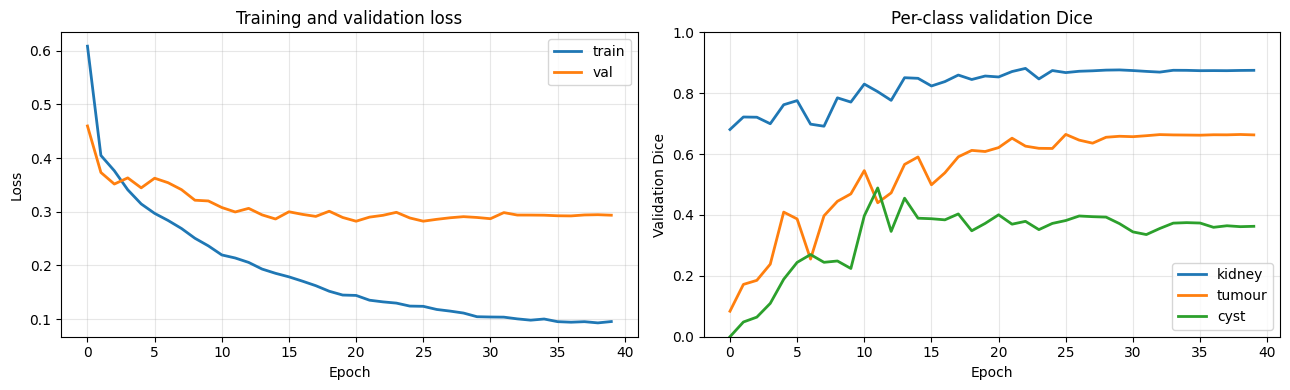

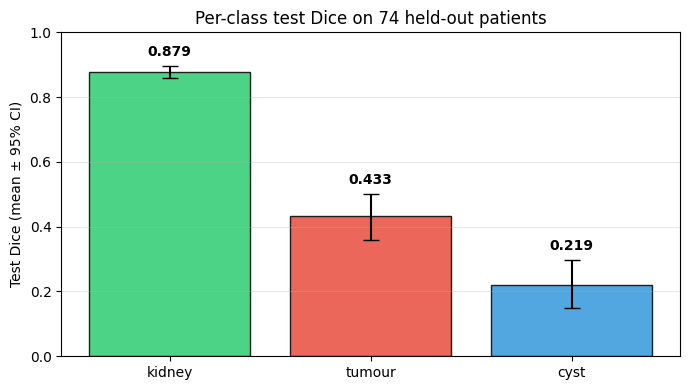

/tmp/ipykernel_2248/3627443525.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)


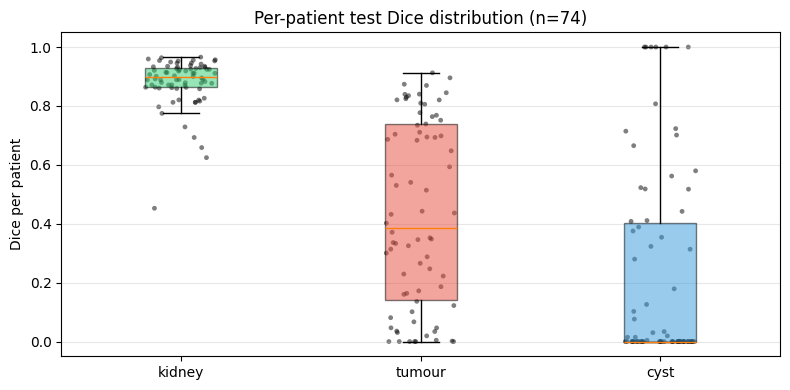

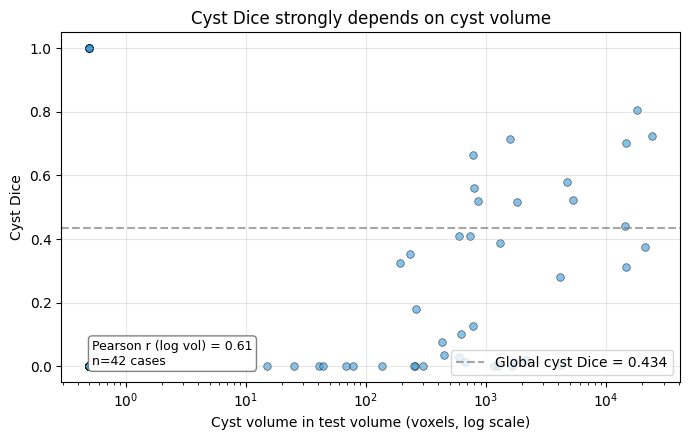

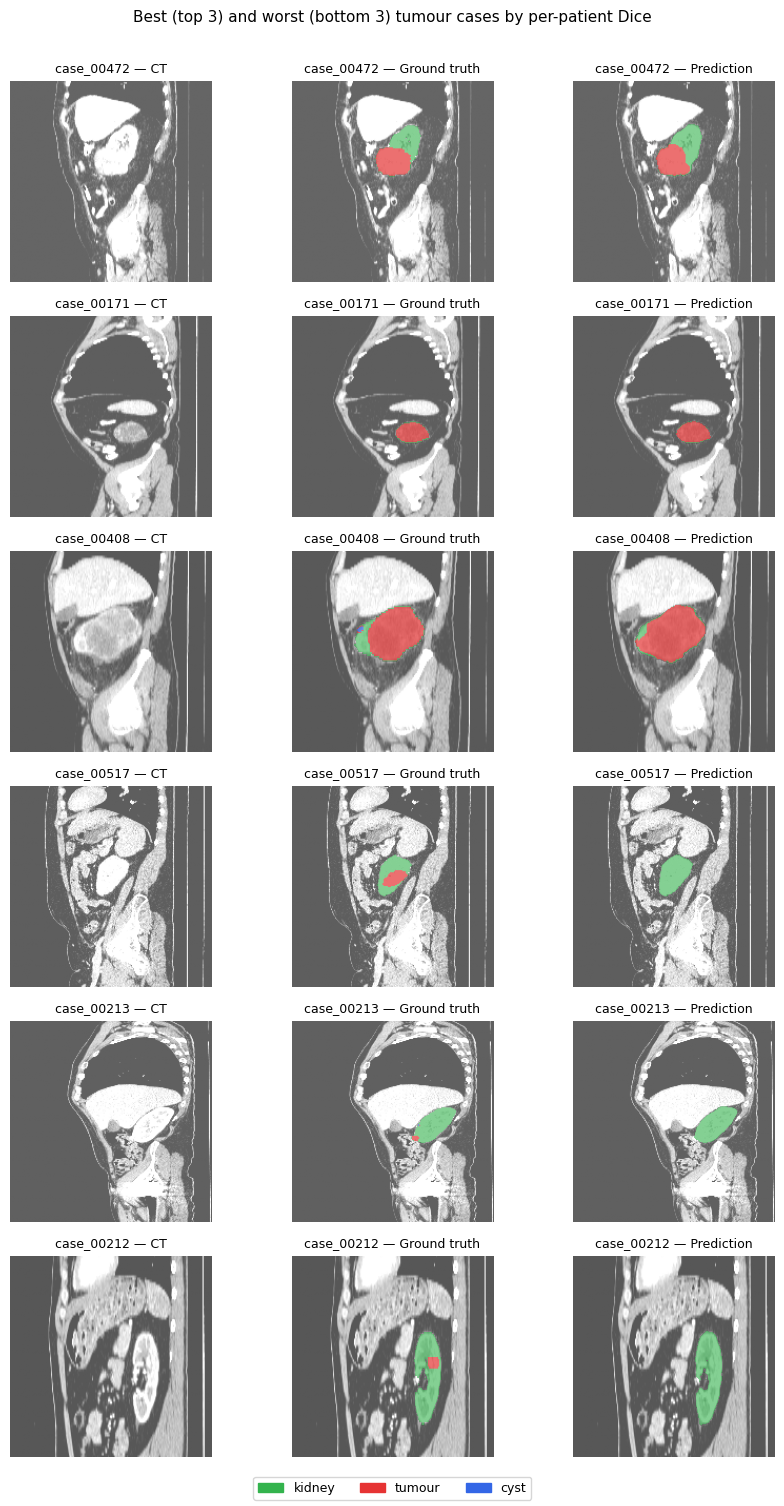


Saved:
  /content/drive/MyDrive/kits23_backup/results/fig1_training_curves.png
  /content/drive/MyDrive/kits23_backup/results/fig2_test_dice_ci.png
  /content/drive/MyDrive/kits23_backup/results/fig3_per_patient_dist.png
  /content/drive/MyDrive/kits23_backup/results/fig4_cyst_volume_vs_dice.png
  /content/drive/MyDrive/kits23_backup/results/fig5_best_worst_cases.png
  /content/drive/MyDrive/kits23_backup/results/test_summary.csv
  /content/drive/MyDrive/kits23_backup/results/per_patient_dice.pkl


In [39]:
# =========================================================
# CELL C9 — Test eval + per-patient Dice + bootstrap CI + FIGURES
# =========================================================
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Class colormap: background transparent, kidney green, tumour red, cyst blue
CLASS_COLORS = ListedColormap([
    (0, 0, 0, 0),        # 0 background - transparent
    (0.2, 0.7, 0.3, 0.6),  # 1 kidney - green
    (0.9, 0.2, 0.2, 0.7),  # 2 tumour - red
    (0.2, 0.4, 0.9, 0.7),  # 3 cyst   - blue
])


@torch.no_grad()
def per_patient_dice(model, case_ids, num_classes=NUM_CLASSES, eps=1e-6):
    model.eval()
    results = {}
    for cid in tqdm(case_ids, desc="Per-patient Dice"):
        img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
        D = img.shape[0]

        inter = np.zeros(num_classes, dtype=np.float64)
        union = np.zeros(num_classes, dtype=np.float64)

        chunk = 8
        for start in range(0, D, chunk):
            end = min(start + chunk, D)
            idxs = list(range(start, end))
            stacks, labels = [], []
            for i in idxs:
                half = SLICE_DEPTH // 2
                js = [min(max(i + d, 0), D - 1) for d in range(-half, half + 1)]
                stacks.append(np.stack([img[j] for j in js], axis=0))
                labels.append(seg[i])
            xb = torch.from_numpy(np.stack(stacks, 0).astype(np.float32)).to(device)
            yb = torch.from_numpy(np.stack(labels, 0).astype(np.int64)).to(device)
            preds = model(xb).argmax(1)
            for c in range(num_classes):
                p = (preds == c)
                t = (yb == c)
                inter[c] += (p & t).sum().item()
                union[c] += p.sum().item() + t.sum().item()

        # Also record class volumes for later volume-vs-Dice plot
        tumour_voxels = int((seg == 2).sum())
        cyst_voxels   = int((seg == 3).sum())

        results[cid] = {
            **{f"dice_{c}": (2 * inter[c] + eps) / (union[c] + eps)
               for c in range(num_classes)},
            "tumour_voxels": tumour_voxels,
            "cyst_voxels": cyst_voxels,
        }
    return results


def bootstrap_ci(values, n_boot=1000, alpha=0.05):
    values = np.asarray(values)
    rng = np.random.default_rng(SEED)
    boots = [np.mean(rng.choice(values, len(values), replace=True))
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(np.mean(values)), float(lo), float(hi)


# --- Global test Dice ---
test_loss, test_dice = evaluate_seg(model, test_loader, class_weights=CLASS_WEIGHTS)
print(f"TEST loss: {test_loss:.4f}")
print("Global (voxel-accumulated) test Dice:")
for c, name in enumerate(CLASS_NAMES):
    print(f"  Dice {name:12s}: {test_dice[c]:.3f}")

# --- Per-patient Dice + CI ---
pp = per_patient_dice(model, test_ids)
print("\nPer-patient mean Dice with 95% CI:")
for c, name in enumerate(CLASS_NAMES):
    vals = [pp[cid][f"dice_{c}"] for cid in pp]
    mean, lo, hi = bootstrap_ci(vals)
    print(f"  {name:12s}: {mean:.3f}  [{lo:.3f}, {hi:.3f}]")


# =========================================================
# FIGURE 1 — Training curves (loss + Dice per class)
# =========================================================
with open(RESULT_DIR / "history.pkl", "rb") as f:
    h = pickle.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(h["train_loss"], label="train", lw=2)
axes[0].plot(h["val_loss"], label="val", lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training and validation loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(h["val_dice_kidney"], label="kidney", lw=2)
axes[1].plot(h["val_dice_tumour"], label="tumour", lw=2)
axes[1].plot(h["val_dice_cyst"],   label="cyst",   lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Dice")
axes[1].set_title("Per-class validation Dice")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULT_DIR / "fig1_training_curves.png", dpi=150)
plt.show()


# =========================================================
# FIGURE 2 — Test Dice bar chart with 95% CI error bars
# =========================================================
fig, ax = plt.subplots(figsize=(7, 4))

names, means, los, his = [], [], [], []
for c, name in enumerate(CLASS_NAMES[1:], start=1):  # skip background
    vals = [pp[cid][f"dice_{c}"] for cid in pp]
    m, lo, hi = bootstrap_ci(vals)
    names.append(name); means.append(m)
    los.append(m - lo); his.append(hi - m)

x = np.arange(len(names))
err = np.array([los, his])
bars = ax.bar(x, means, yerr=err, capsize=6,
              color=["#2ecc71", "#e74c3c", "#3498db"], alpha=0.85,
              edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("Test Dice (mean ± 95% CI)")
ax.set_title("Per-class test Dice on 74 held-out patients")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis="y")

# Annotate values
for i, (m, lo, hi) in enumerate(zip(means, los, his)):
    ax.text(i, m + hi + 0.03, f"{m:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(RESULT_DIR / "fig2_test_dice_ci.png", dpi=150)
plt.show()


# =========================================================
# FIGURE 3 — Per-patient Dice distributions (box + scatter)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 4))

data, labels = [], []
for c, name in enumerate(CLASS_NAMES[1:], start=1):
    vals = [pp[cid][f"dice_{c}"] for cid in pp]
    data.append(vals); labels.append(name)

bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ["#2ecc71", "#e74c3c", "#3498db"]):
    patch.set_facecolor(color); patch.set_alpha(0.5)

# Overlay individual patient points (jittered)
rng = np.random.default_rng(SEED)
for i, vals in enumerate(data, start=1):
    jitter = rng.uniform(-0.15, 0.15, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               s=12, alpha=0.5, color="black", edgecolor="none")

ax.set_ylabel("Dice per patient")
ax.set_title("Per-patient test Dice distribution (n=74)")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULT_DIR / "fig3_per_patient_dist.png", dpi=150)
plt.show()


# =========================================================
# FIGURE 4 — Cyst Dice vs cyst volume (the key explanation plot)
# =========================================================
fig, ax = plt.subplots(figsize=(7, 4.5))

cyst_pts = [(pp[cid]["cyst_voxels"], pp[cid]["dice_3"]) for cid in pp]
cv = np.array([p[0] for p in cyst_pts])
cd = np.array([p[1] for p in cyst_pts])

# Jitter zeros slightly for visibility on log axis
cv_plot = np.where(cv == 0, 0.5, cv)
ax.scatter(cv_plot, cd, s=30, alpha=0.6, color="#3498db", edgecolor="black", lw=0.5)
ax.set_xscale("log")
ax.set_xlabel("Cyst volume in test volume (voxels, log scale)")
ax.set_ylabel("Cyst Dice")
ax.set_title("Cyst Dice strongly depends on cyst volume")
ax.axhline(test_dice[3], ls="--", color="gray", alpha=0.7,
           label=f"Global cyst Dice = {test_dice[3]:.3f}")
ax.grid(alpha=0.3)

# Annotate correlation on non-zero points
mask = cv > 0
if mask.sum() > 5:
    r = np.corrcoef(np.log(cv[mask]), cd[mask])[0, 1]
    ax.text(0.05, 0.05, f"Pearson r (log vol) = {r:.2f}\nn={mask.sum()} cases",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="gray"))

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULT_DIR / "fig4_cyst_volume_vs_dice.png", dpi=150)
plt.show()


# =========================================================
# FIGURE 5 — Segmentation overlays (3 best + 3 worst tumour cases)
# =========================================================
def render_case(cid, ax_row):
    img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
    D = img.shape[0]

    # find centre slice with most tumour
    tumour_per_slice = (seg == 2).sum(axis=(1, 2))
    if tumour_per_slice.max() > 0:
        centre = int(np.argmax(tumour_per_slice))
    else:
        centre = D // 2

    half = SLICE_DEPTH // 2
    js = [min(max(centre + d, 0), D - 1) for d in range(-half, half + 1)]
    stack = np.stack([img[j] for j in js], axis=0).astype(np.float32)
    xb = torch.from_numpy(stack[None]).to(device)
    with torch.no_grad():
        pred = model(xb).argmax(1)[0].cpu().numpy()

    ct = stack[half]
    gt = seg[centre]

    for col, (title, overlay) in enumerate([
        ("CT", None), ("Ground truth", gt), ("Prediction", pred)
    ]):
        ax = ax_row[col]
        ax.imshow(ct, cmap="gray", vmin=-2, vmax=2)
        if overlay is not None:
            ax.imshow(overlay, cmap=CLASS_COLORS, vmin=0, vmax=3)
        ax.set_title(f"{cid} — {title}", fontsize=9)
        ax.axis("off")


# Rank by tumour Dice
ranked = sorted(pp.keys(), key=lambda c: pp[c]["dice_2"])
worst3 = ranked[:3]
best3  = ranked[-3:]

fig, axes = plt.subplots(6, 3, figsize=(9, 15))
for row, cid in enumerate(best3):
    render_case(cid, axes[row])
axes[0, 0].set_ylabel("Best tumour", fontsize=10)  # label hint

for row, cid in enumerate(worst3, start=3):
    render_case(cid, axes[row])

# Add legend
legend_patches = [
    mpatches.Patch(color=(0.2, 0.7, 0.3), label="kidney"),
    mpatches.Patch(color=(0.9, 0.2, 0.2), label="tumour"),
    mpatches.Patch(color=(0.2, 0.4, 0.9), label="cyst"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=9)

plt.suptitle("Best (top 3) and worst (bottom 3) tumour cases by per-patient Dice",
             fontsize=11, y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.savefig(RESULT_DIR / "fig5_best_worst_cases.png", dpi=120)
plt.show()


# =========================================================
# Save all results
# =========================================================
with open(RESULT_DIR / "per_patient_dice.pkl", "wb") as f:
    pickle.dump(pp, f)

# Summary CSV for thesis table
import csv
with open(RESULT_DIR / "test_summary.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["class", "global_dice", "per_patient_mean", "ci_low", "ci_high"])
    for c, name in enumerate(CLASS_NAMES):
        vals = [pp[cid][f"dice_{c}"] for cid in pp]
        m, lo, hi = bootstrap_ci(vals)
        w.writerow([name, f"{test_dice[c]:.4f}", f"{m:.4f}", f"{lo:.4f}", f"{hi:.4f}"])

print("\nSaved:")
print(f"  {RESULT_DIR / 'fig1_training_curves.png'}")
print(f"  {RESULT_DIR / 'fig2_test_dice_ci.png'}")
print(f"  {RESULT_DIR / 'fig3_per_patient_dist.png'}")
print(f"  {RESULT_DIR / 'fig4_cyst_volume_vs_dice.png'}")
print(f"  {RESULT_DIR / 'fig5_best_worst_cases.png'}")
print(f"  {RESULT_DIR / 'test_summary.csv'}")
print(f"  {RESULT_DIR / 'per_patient_dice.pkl'}")

Confusion:   0%|          | 0/100 [00:00<?, ?it/s]

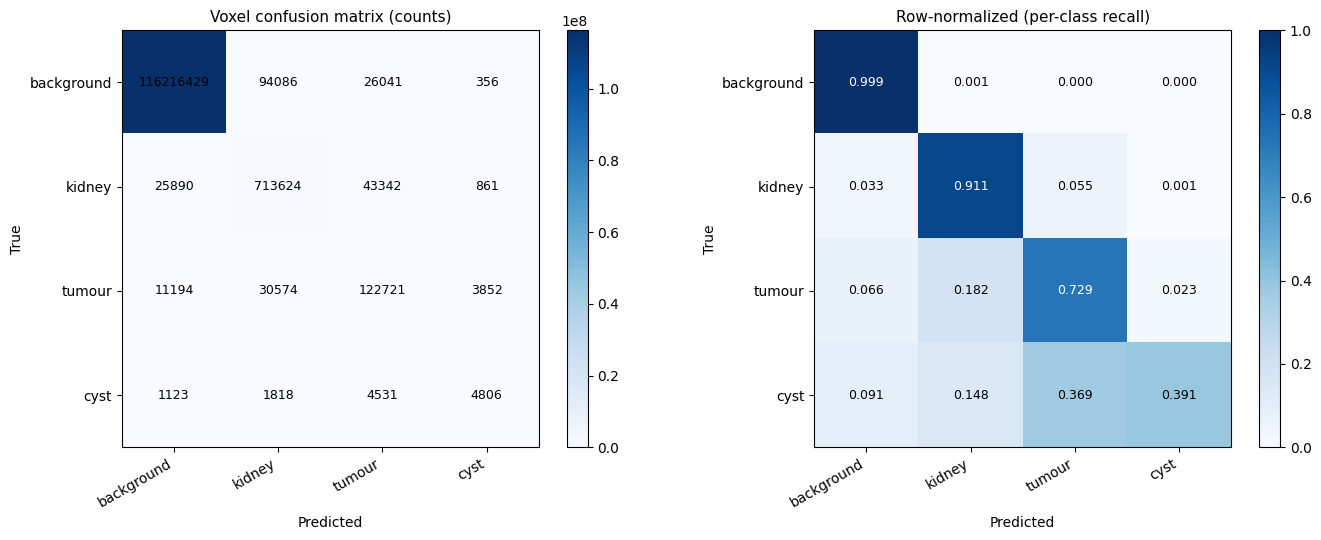


Per-class metrics from confusion matrix:
class         precision     recall         F1      support
background        1.000      0.999      0.999    116336912
kidney            0.849      0.911      0.879       783717
tumour            0.624      0.729      0.672       168341
cyst              0.487      0.391      0.434        12278

Saved /content/drive/MyDrive/kits23_backup/results/fig6_confusion_matrix.png
Saved /content/drive/MyDrive/kits23_backup/results/per_class_metrics.csv


In [40]:
# =========================================================
# FIGURE 6 — Confusion matrices (voxel counts + row-normalized)
# =========================================================
from sklearn.metrics import confusion_matrix
import itertools

@torch.no_grad()
def collect_confusion(model, loader, num_classes=NUM_CLASSES):
    """Sum confusion across whole test loader: rows=true, cols=pred."""
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for xb, yb in tqdm(loader, desc="Confusion"):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        preds = model(xb).argmax(1)
        # Flatten batch + spatial
        y_true = yb.cpu().numpy().ravel()
        y_pred = preds.cpu().numpy().ravel()
        cm += confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    return cm


cm = collect_confusion(model, test_loader)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)


def plot_cm(ax, mat, title, fmt, vmin=None, vmax=None, cmap="Blues"):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=11)

    # Text annotations
    for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
        val = mat[i, j]
        txt = fmt.format(val)
        # Choose text colour for contrast
        if vmax is not None and val > 0.5 * vmax:
            color = "white"
        else:
            color = "black"
        ax.text(j, i, txt, ha="center", va="center",
                color=color, fontsize=9)

    return im


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Raw counts (log-scaled colour so background doesn't dominate)
im0 = plot_cm(axes[0], cm, "Voxel confusion matrix (counts)",
              fmt="{:.0f}", vmin=0, vmax=None, cmap="Blues")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Row-normalized (per-class recall)
im1 = plot_cm(axes[1], cm_norm, "Row-normalized (per-class recall)",
              fmt="{:.3f}", vmin=0, vmax=1, cmap="Blues")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(RESULT_DIR / "fig6_confusion_matrix.png", dpi=150)
plt.show()


# =========================================================
# FIGURE 6b — Per-class recall / precision / F1 table
# =========================================================
print("\nPer-class metrics from confusion matrix:")
print(f"{'class':12s} {'precision':>10s} {'recall':>10s} {'F1':>10s} {'support':>12s}")
for c, name in enumerate(CLASS_NAMES):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    support = cm[c, :].sum()
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-9)
    print(f"{name:12s} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f} {support:>12d}")

# Save to CSV
with open(RESULT_DIR / "per_class_metrics.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["class", "precision", "recall", "f1", "support"])
    for c, name in enumerate(CLASS_NAMES):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-9)
        w.writerow([name, f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", int(cm[c, :].sum())])

print(f"\nSaved {RESULT_DIR / 'fig6_confusion_matrix.png'}")
print(f"Saved {RESULT_DIR / 'per_class_metrics.csv'}")

In [43]:
from google.colab import files
import os
for f in ["fig1_training_curves.png", "fig2_test_dice_ci.png",
          "fig3_per_patient_dist.png", "fig4_cyst_volume_vs_dice.png",
          "fig5_best_worst_cases.png", "fig6_confusion_matrix.png",
          "test_summary.csv", "per_class_metrics.csv"]:
    files.download(str(RESULT_DIR / f))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
# =========================================================
# CELL C10 — MC Dropout setup + inference
# =========================================================
import torch.nn as nn

# 1) Add dropout to the model (post-hoc, no retraining needed)
def inject_dropout(model, p=0.3):
    """Insert Dropout2d after each ReLU in the network."""
    new_layers = []
    for name, mod in model.named_children():
        if isinstance(mod, nn.Sequential):
            new_seq = []
            for layer in mod:
                new_seq.append(layer)
                if isinstance(layer, nn.ReLU):
                    new_seq.append(nn.Dropout2d(p=p, inplace=False))
            new_layers.append((name, nn.Sequential(*new_seq)))
        elif isinstance(mod, nn.Module):
            # Recurse into submodules (DoubleConv.net etc.)
            for sub_name, sub_mod in mod.named_children():
                if isinstance(sub_mod, nn.Sequential):
                    new_sub = []
                    for layer in sub_mod:
                        new_sub.append(layer)
                        if isinstance(layer, nn.ReLU):
                            new_sub.append(nn.Dropout2d(p=p, inplace=False))
                    setattr(mod, sub_name, nn.Sequential(*new_sub))
            new_layers.append((name, mod))
        else:
            new_layers.append((name, mod))
    for name, mod in new_layers:
        setattr(model, name, mod)
    return model


def enable_mc_dropout(model):
    """Put model in eval mode BUT keep dropout layers active."""
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()


@torch.no_grad()
def mc_dropout_predict(model, x, n_passes=20):
    """
    Returns:
      mean_probs: [C, H, W]  — mean softmax over passes
      var_probs:  [C, H, W]  — variance of softmax over passes
      pred:       [H, W]     — argmax of mean_probs
      entropy:    [H, W]     — predictive entropy
    """
    enable_mc_dropout(model)
    probs_all = []
    for _ in range(n_passes):
        logits = model(x)          # x: [1, 3, H, W]
        probs = F.softmax(logits, dim=1)
        probs_all.append(probs[0]) # [C, H, W]
    probs_stack = torch.stack(probs_all, dim=0)   # [N, C, H, W]

    mean_probs = probs_stack.mean(0)
    var_probs  = probs_stack.var(0)
    pred       = mean_probs.argmax(0)

    # Predictive entropy
    eps = 1e-8
    entropy = -(mean_probs * (mean_probs + eps).log()).sum(0)

    return mean_probs.cpu(), var_probs.cpu(), pred.cpu(), entropy.cpu()


# Inject dropout
model = inject_dropout(model, p=0.3)
n_dropout = sum(1 for m in model.modules() if isinstance(m, (nn.Dropout, nn.Dropout2d)))
print(f"Injected dropout layers: {n_dropout}")

# =========================================================
# Smoke test WITHOUT DataLoader (avoids worker-death issue)
# =========================================================
enable_mc_dropout(model)

# Load one cached volume directly
cid = test_ids[0]
img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
D = img.shape[0]
centre = D // 2
half = SLICE_DEPTH // 2
js = [min(max(centre + d, 0), D - 1) for d in range(-half, half + 1)]
stack = np.stack([img[j] for j in js], axis=0).astype(np.float32)
x = torch.from_numpy(stack[None]).to(device)

m1 = model(x)
m2 = model(x)
diff = (m1 - m2).abs().max().item()
print(f"Determinism check (should differ): max diff = {diff:.4f}")
assert diff > 1e-4, "Dropout not active — model outputs are identical"
print("✅ Dropout is active — MC inference will produce variability.")

Injected dropout layers: 36
Determinism check (should differ): max diff = 118.9528
✅ Dropout is active — MC inference will produce variability.


In [46]:
# Inspect raw logit magnitudes
enable_mc_dropout(model)
with torch.no_grad():
    logits = model(x)
print(f"Logit min/max: {logits.min().item():.2f} / {logits.max().item():.2f}")
print(f"Logit shape:   {tuple(logits.shape)}")
print(f"Logit mean:    {logits.mean().item():.4f}")
print(f"Logit std:     {logits.std().item():.4f}")

Logit min/max: -50.05 / 39.71
Logit shape:   (1, 4, 192, 192)
Logit mean:    -2.0377
Logit std:     7.4772


In [47]:
# =========================================================
# CELL C11 — MC Dropout on all test patients
# =========================================================
N_PASSES = 20

mc_results = {}  # cid -> dict of per-slice arrays

@torch.no_grad()
def mc_dropout_patient(model, cid, n_passes=N_PASSES):
    """Run MC Dropout on every slice of one patient."""
    img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
    D = img.shape[0]
    half = SLICE_DEPTH // 2

    all_var = []
    all_pred = []
    all_gt = []
    all_entropy = []

    for i in range(D):
        js = [min(max(i + d, 0), D - 1) for d in range(-half, half + 1)]
        stack = np.stack([img[j] for j in js], axis=0).astype(np.float32)
        x = torch.from_numpy(stack[None]).to(device)

        mean_probs, var_probs, pred, entropy = mc_dropout_predict(model, x, n_passes)

        all_var.append(var_probs[2].numpy())     # tumour class variance
        all_pred.append(pred.numpy())
        all_gt.append(seg[i])
        all_entropy.append(entropy.numpy())

    return {
        "var_tumour": np.stack(all_var),
        "pred":       np.stack(all_pred),
        "gt":         np.stack(all_gt),
        "entropy":    np.stack(all_entropy),
    }


print(f"Running MC Dropout ({N_PASSES} passes) on {len(test_ids)} test patients...")
for cid in tqdm(test_ids, desc="MC Dropout"):
    mc_results[cid] = mc_dropout_patient(model, cid)

with open(RESULT_DIR / "mc_dropout_results.pkl", "wb") as f:
    pickle.dump(mc_results, f)

print(f"\nSaved MC Dropout results for {len(mc_results)} patients")

Running MC Dropout (20 passes) on 74 test patients...


MC Dropout:   0%|          | 0/74 [00:00<?, ?it/s]


Saved MC Dropout results for 74 patients


In [49]:
# =========================================================
# CELL C12 (fast) — Calibration + AUC on sampled voxels
# =========================================================
from sklearn.metrics import roc_auc_score
import csv

# Sample 1M voxels for AUC (AUC converges fast; 1M is plenty)
rng = np.random.default_rng(SEED)
n_total = len(all_var)
n_sample = min(1_000_000, n_total)
idx = rng.choice(n_total, n_sample, replace=False)

var_s = all_var[idx]
ent_s = all_entropy[idx]
err_s = (1 - all_correct[idx]).astype(np.float32)  # 1=incorrect

if err_s.min() < 1 and err_s.max() > 0:
    auc_var = roc_auc_score(err_s, var_s)
    auc_ent = roc_auc_score(err_s, ent_s)
    print(f"Error-detection AUC (variance, n={n_sample:,}):  {auc_var:.4f}")
    print(f"Error-detection AUC (entropy,  n={n_sample:,}):  {auc_ent:.4f}")
else:
    auc_var = auc_ent = float("nan")
    print("Cannot compute AUC on sample — adjust sample or seed.")

# Save
with open(RESULT_DIR / "calibration_metrics.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["threshold", "RCC", "RIU", "frac_uncertain"])
    for t, rcc, riu, fu in calib_rows:
        w.writerow([f"{t:.6f}", f"{rcc:.4f}", f"{riu:.4f}", f"{fu:.4f}"])
    w.writerow([])
    w.writerow(["error_detection_auc_var", f"{auc_var:.4f}"])
    w.writerow(["error_detection_auc_entropy", f"{auc_ent:.4f}"])

print(f"\nSaved {RESULT_DIR / 'calibration_metrics.csv'}")
print(f"AUC computed on {n_sample:,} / {n_total:,} voxels (random sample).")

Error-detection AUC (variance, n=1,000,000):  0.7491
Error-detection AUC (entropy,  n=1,000,000):  0.8612

Saved /content/drive/MyDrive/kits23_backup/results/calibration_metrics.csv
AUC computed on 1,000,000 / 1,396,703,232 voxels (random sample).


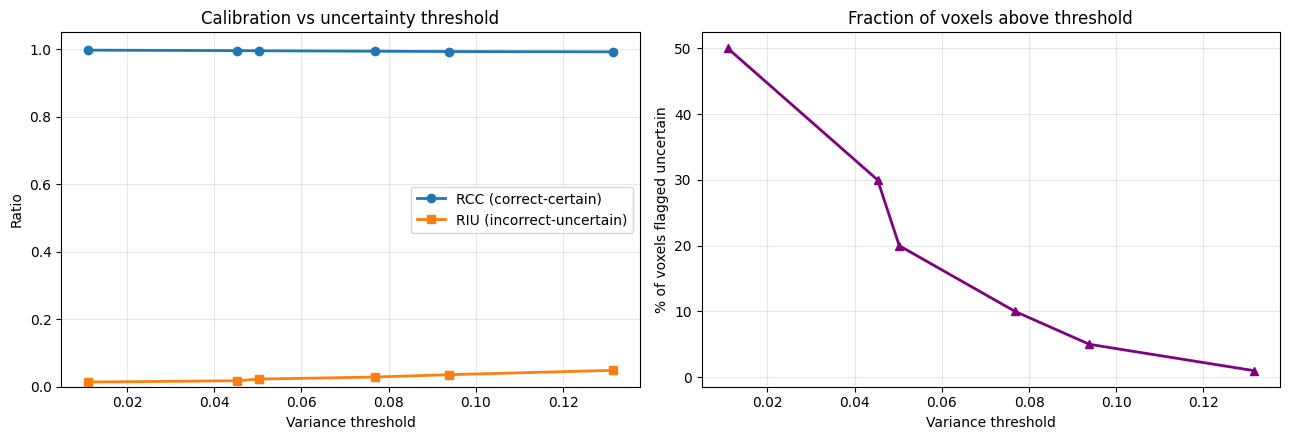

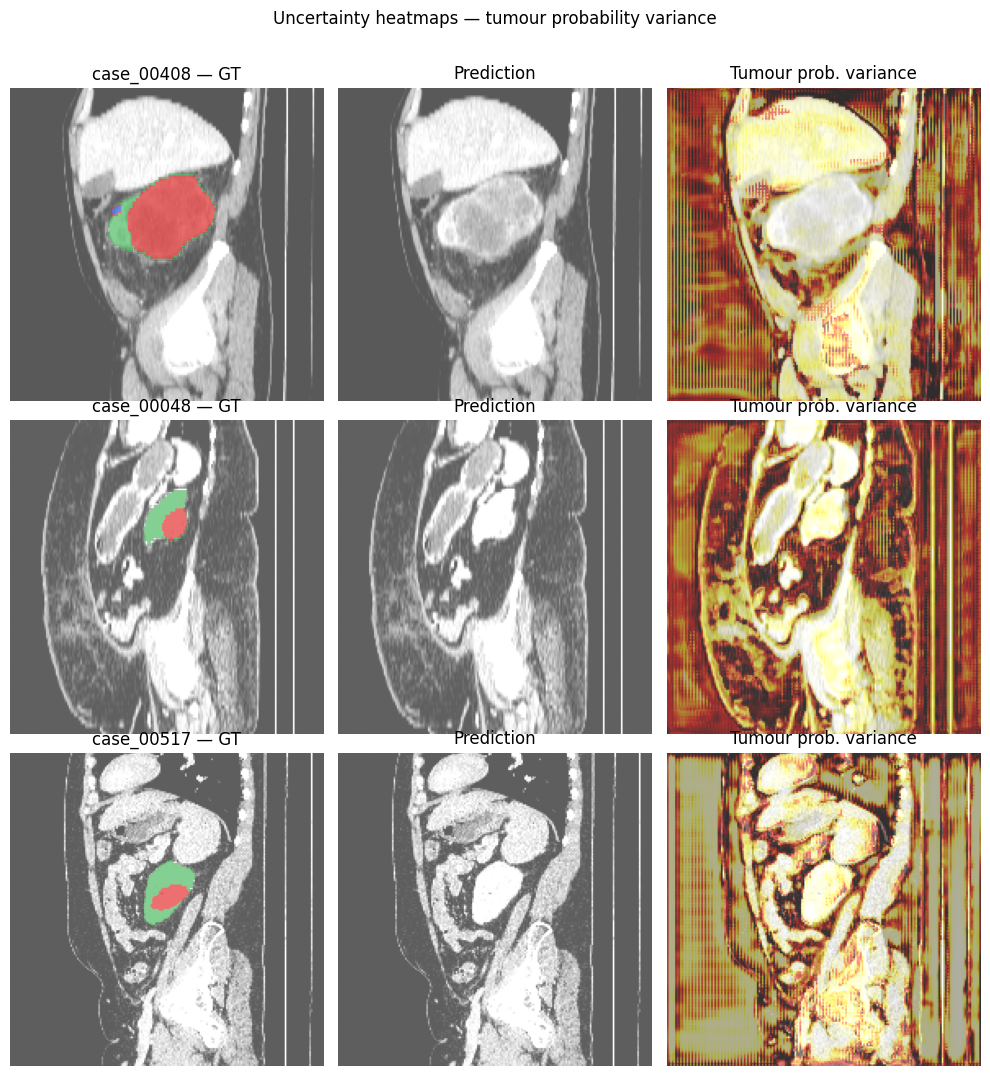

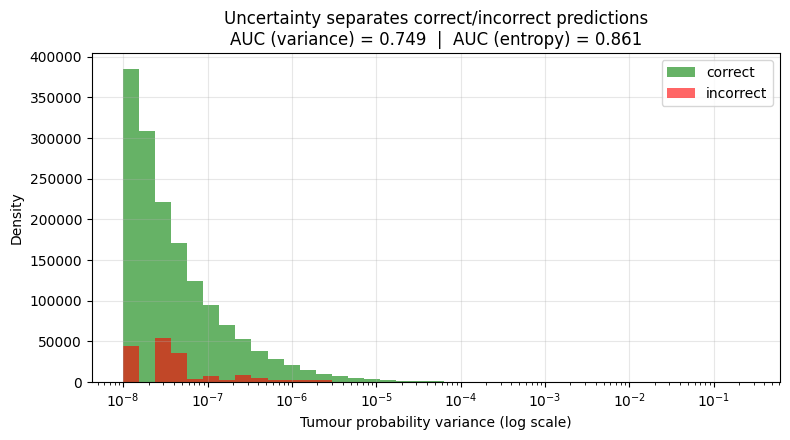


Saved:
  /content/drive/MyDrive/kits23_backup/results/fig7_calibration.png
  /content/drive/MyDrive/kits23_backup/results/fig8_uncertainty_heatmaps.png
  /content/drive/MyDrive/kits23_backup/results/fig9_uncertainty_vs_error.png


In [50]:
# =========================================================
# CELL C13 — Uncertainty figures
# =========================================================
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ------- FIGURE 7: Calibration curves -------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ths = [r[0] for r in calib_rows]
rccs = [r[1] for r in calib_rows]
rius = [r[2] for r in calib_rows]
fus  = [100 * r[3] for r in calib_rows]

axes[0].plot(ths, rccs, "o-", label="RCC (correct-certain)", lw=2)
axes[0].plot(ths, rius, "s-", label="RIU (incorrect-uncertain)", lw=2)
axes[0].set_xlabel("Variance threshold")
axes[0].set_ylabel("Ratio")
axes[0].set_title("Calibration vs uncertainty threshold")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

axes[1].plot(ths, fus, "^-", color="purple", lw=2)
axes[1].set_xlabel("Variance threshold")
axes[1].set_ylabel("% of voxels flagged uncertain")
axes[1].set_title("Fraction of voxels above threshold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / "fig7_calibration.png", dpi=150)
plt.show()


# ------- FIGURE 8: Uncertainty heatmaps (best, median, worst) -------
CLASS_COLORS = ListedColormap([
    (0, 0, 0, 0),
    (0.2, 0.7, 0.3, 0.6),
    (0.9, 0.2, 0.2, 0.7),
    (0.2, 0.4, 0.9, 0.7),
])


def render_uncertainty_case(cid, ax_row):
    r = mc_results[cid]
    var = r["var_tumour"]
    pred = r["pred"]
    gt = r["gt"]
    img, _ = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
    D = img.shape[0]

    tumour_per_slice = (gt == 2).sum(axis=(1, 2))
    centre = int(np.argmax(tumour_per_slice)) if tumour_per_slice.max() > 0 else D // 2

    ct = img[centre]
    v = var[centre]
    p = pred[centre]
    g = gt[centre]

    ax_row[0].imshow(ct, cmap="gray", vmin=-2, vmax=2)
    ax_row[0].imshow(g, cmap=CLASS_COLORS, vmin=0, vmax=3)
    ax_row[0].set_title(f"{cid} — GT"); ax_row[0].axis("off")

    ax_row[1].imshow(ct, cmap="gray", vmin=-2, vmax=2)
    ax_row[1].imshow(p, cmap=CLASS_COLORS, vmin=0, vmax=3)
    ax_row[1].set_title("Prediction"); ax_row[1].axis("off")

    ax_row[2].imshow(ct, cmap="gray", vmin=-2, vmax=2)
    v_show = np.log10(v + 1e-8)
    vmin, vmax = np.percentile(v_show, [5, 99])
    im = ax_row[2].imshow(v_show, cmap="hot", alpha=0.5, vmin=vmin, vmax=vmax)
    ax_row[2].set_title("Tumour prob. variance")
    ax_row[2].axis("off")
    return im


ranked = sorted(mc_results.keys(),
                key=lambda c: pp[c]["dice_2"] if c in pp else 0)
sample_ids = [ranked[-1], ranked[len(ranked) // 2], ranked[0]]
titles = ["Best tumour Dice", "Median tumour Dice", "Worst tumour Dice"]

fig, axes = plt.subplots(3, 3, figsize=(10, 11))
last_im = None
for row, (cid, title) in enumerate(zip(sample_ids, titles)):
    last_im = render_uncertainty_case(cid, axes[row])
    axes[row, 0].set_ylabel(title, fontsize=10, rotation=90,
                            labelpad=40, va="center")

plt.suptitle("Uncertainty heatmaps — tumour probability variance",
             fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.savefig(RESULT_DIR / "fig8_uncertainty_heatmaps.png", dpi=140)
plt.show()


# ------- FIGURE 9: Uncertainty vs correctness (histogram) -------
fig, ax = plt.subplots(figsize=(8, 4.5))

n_sample = min(1_000_000, len(all_var))
idx = np.random.default_rng(SEED).choice(len(all_var), n_sample, replace=False)
var_s = all_var[idx]
correct_s = all_correct[idx]

bins = np.logspace(np.log10(all_var.min() + 1e-8),
                   np.log10(all_var.max() + 1e-8), 40)

ax.hist(var_s[correct_s == 1], bins=bins, alpha=0.6,
        label="correct", color="green", density=True)
ax.hist(var_s[correct_s == 0], bins=bins, alpha=0.6,
        label="incorrect", color="red", density=True)
ax.set_xscale("log")
ax.set_xlabel("Tumour probability variance (log scale)")
ax.set_ylabel("Density")
ax.set_title(f"Uncertainty separates correct/incorrect predictions\n"
             f"AUC (variance) = {auc_var:.3f}  |  AUC (entropy) = {auc_ent:.3f}")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / "fig9_uncertainty_vs_error.png", dpi=150)
plt.show()


print("\nSaved:")
print(f"  {RESULT_DIR / 'fig7_calibration.png'}")
print(f"  {RESULT_DIR / 'fig8_uncertainty_heatmaps.png'}")
print(f"  {RESULT_DIR / 'fig9_uncertainty_vs_error.png'}")

In [51]:
# =========================================================
# CELL C14 — Download all figures to local machine
# =========================================================
from google.colab import files
for f in ["fig1_training_curves.png",
          "fig2_test_dice_ci.png",
          "fig3_per_patient_dist.png",
          "fig4_cyst_volume_vs_dice.png",
          "fig5_best_worst_cases.png",
          "fig6_confusion_matrix.png",
          "fig7_calibration.png",
          "fig8_uncertainty_heatmaps.png",
          "fig9_uncertainty_vs_error.png",
          "test_summary.csv",
          "per_class_metrics.csv",
          "calibration_metrics.csv"]:
    files.download(str(RESULT_DIR / f))
print("All downloads triggered.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloads triggered.


In [52]:
# =========================================================
# CELL ABL0 — Set up ablation output directories
# =========================================================
from pathlib import Path

ABL_ROOT = Path("/content/drive/MyDrive/kits23_backup/ablations")
ABL_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Ablation root: {ABL_ROOT}")
print(f"Main results remain at: /content/drive/MyDrive/kits23_backup/results")
print(f"Main models remain at:  /content/drive/MyDrive/kits23_backup/models")

Ablation root: /content/drive/MyDrive/kits23_backup/ablations
Main results remain at: /content/drive/MyDrive/kits23_backup/results
Main models remain at:  /content/drive/MyDrive/kits23_backup/models


In [53]:
# =========================================================
# CELL ABL1-C2 — Config for 2D ablation (depth=1)
# =========================================================
import os, math, random, pickle, time
from pathlib import Path
from collections import defaultdict
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Paths
DATASET_DIR = Path("/content/kits23_dataset/dataset")
CACHE_DIR   = Path("/content/seg_cache")   # shared

ABL_ROOT  = Path("/content/drive/MyDrive/kits23_backup/ablations")
SPLIT_DIR = Path("/content/drive/MyDrive/kits23_backup/seg_splits")  # shared
MODEL_DIR = ABL_ROOT / "2d" / "models"
RESULT_DIR = ABL_ROOT / "2d" / "results"

for d in [MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Classes
NUM_CLASSES = 4
CLASS_NAMES = ["background", "kidney", "tumour", "cyst"]

# Preprocessing
SLICE_SIZE = 192
SLICE_DEPTH = 1             # ← ABLATION: 2D
HU_MIN, HU_MAX = -100, 300

# Training
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 1e-3
SEED = 42
NUM_WORKERS = 4

CLASS_WEIGHTS = [0.1, 1.0, 3.0, 5.0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print(f"ABLATION: 2D (SLICE_DEPTH={SLICE_DEPTH})")
print(f"MODEL_DIR:  {MODEL_DIR}")
print(f"RESULT_DIR: {RESULT_DIR}")

ABLATION: 2D (SLICE_DEPTH=1)
MODEL_DIR:  /content/drive/MyDrive/kits23_backup/ablations/2d/models
RESULT_DIR: /content/drive/MyDrive/kits23_backup/ablations/2d/results


In [54]:
# =========================================================
# CELL ABL1-C5 — Dataset + loaders (depth=1)
# =========================================================
@lru_cache(maxsize=4)
def _load_npz_cached(path_str):
    d = np.load(path_str)
    return d["image"], d["seg"]


class KiTSSegDataset(Dataset):
    def __init__(self, case_ids, depth=SLICE_DEPTH, train=False,
                 slices_per_patient=None, stride=12, fg_ratio=0.8):
        self.case_ids = list(case_ids)
        self.depth = depth
        self.train = train
        self.slices_per_patient = slices_per_patient
        self.stride = stride
        self.fg_ratio = fg_ratio

        self.fg_per_case = {}
        if train and slices_per_patient:
            for cid in self.case_ids:
                _, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
                fg = np.where((seg != 0).any(axis=(1, 2)))[0]
                self.fg_per_case[cid] = fg

        self._build_index()

    def _build_index(self):
        self.index = []
        for cid in self.case_ids:
            _, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
            D = seg.shape[0]

            if self.train and self.slices_per_patient:
                fg = self.fg_per_case.get(cid, np.array([], dtype=int))
                n_fg = int(round(self.slices_per_patient * self.fg_ratio))
                n_bg = self.slices_per_patient - n_fg

                if len(fg) >= n_fg and len(fg) > 0:
                    fg_pick = np.random.choice(fg, n_fg, replace=False)
                else:
                    fg_pick = fg if len(fg) > 0 else np.array([], dtype=int)

                bg_pool = np.setdiff1d(np.arange(D), fg, assume_unique=False)
                if len(bg_pool) >= n_bg and n_bg > 0:
                    bg_pick = np.random.choice(bg_pool, n_bg, replace=False)
                else:
                    bg_pick = bg_pool if len(bg_pool) > 0 else np.array([], dtype=int)

                idxs = np.concatenate([fg_pick, bg_pick])
                if len(idxs) == 0:
                    idxs = np.array([D // 2])
            else:
                idxs = np.arange(0, D, self.stride)

            for i in idxs:
                self.index.append((cid, int(i)))

        print(f"  Dataset: {len(self.index)} slices from {len(self.case_ids)} patients"
              f"{' (train)' if self.train else ''}")

    def __len__(self):
        return len(self.index)

    def _load_stack(self, cid, i):
        img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
        D = img.shape[0]
        half = self.depth // 2
        idxs = [min(max(i + d, 0), D - 1) for d in range(-half, half + 1)]
        stack = np.stack([img[j] for j in idxs], axis=0).astype(np.float32)
        label = seg[i].astype(np.int64)
        return stack, label

    def __getitem__(self, idx):
        cid, i = self.index[idx]
        img, seg = self._load_stack(cid, i)
        if self.train:
            if random.random() < 0.5:
                img = img[:, :, ::-1].copy()
                seg = seg[:, ::-1].copy()
            img = img + np.random.randn(*img.shape).astype(np.float32) * 0.05
        return torch.from_numpy(img), torch.from_numpy(seg)

    def resample(self):
        if self.train and self.slices_per_patient:
            self._build_index()


def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_seg_loaders(train_ids, val_ids, test_ids,
                     slices_per_patient=16, fg_ratio=0.8):
    ds_tr = KiTSSegDataset(train_ids, train=True,
                           slices_per_patient=slices_per_patient,
                           stride=1, fg_ratio=fg_ratio)
    ds_va = KiTSSegDataset(val_ids,   train=False, stride=12)
    ds_te = KiTSSegDataset(test_ids,  train=False, stride=12)

    g = torch.Generator(); g.manual_seed(SEED)
    common = dict(num_workers=NUM_WORKERS, pin_memory=True,
                  prefetch_factor=4, persistent_workers=True)

    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                       worker_init_fn=seed_worker, generator=g, **common)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, **common)
    dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, **common)
    return dl_tr, dl_va, dl_te, ds_tr


# Reload splits from disk (shared with main run)
with open(SPLIT_DIR / "train_ids.txt") as f:
    train_ids = [l.strip() for l in f if l.strip()]
with open(SPLIT_DIR / "val_ids.txt") as f:
    val_ids = [l.strip() for l in f if l.strip()]
with open(SPLIT_DIR / "test_ids.txt") as f:
    test_ids = [l.strip() for l in f if l.strip()]

print(f"Splits: {len(train_ids)} / {len(val_ids)} / {len(test_ids)}")

train_loader, val_loader, test_loader, train_ds = make_seg_loaders(
    train_ids, val_ids, test_ids, slices_per_patient=16, fg_ratio=0.8)

xb, yb = next(iter(train_loader))
print(f"Batch: image {tuple(xb.shape)} | seg {tuple(yb.shape)}")

Splits: 342 / 73 / 74
  Dataset: 5472 slices from 342 patients (train)
  Dataset: 3175 slices from 73 patients
  Dataset: 3182 slices from 74 patients
Batch: image (32, 1, 192, 192) | seg (32, 192, 192)


In [55]:
# =========================================================
# CELL ABL1-C6 — 2D U-Net (in_ch=1)
# =========================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class UNet2D(nn.Module):
    def __init__(self, in_ch=1, num_classes=NUM_CLASSES, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 8, base * 16)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)


model = UNet2D(in_ch=SLICE_DEPTH).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"2D U-Net trainable params: {n_params:,}")

2D U-Net trainable params: 7,762,564


In [56]:
# =========================================================
# CELL ABL1-C7 — Loss + global Dice
# =========================================================
def dice_loss(logits, target, num_classes=NUM_CLASSES, eps=1e-6):
    probs = F.softmax(logits, dim=1)
    target_1h = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    inter = (probs * target_1h).sum(dims)
    union = probs.sum(dims) + target_1h.sum(dims)
    return 1.0 - ((2 * inter + eps) / (union + eps)).mean()


def combined_loss(logits, target, class_weights=None):
    if class_weights is not None and not torch.is_tensor(class_weights):
        class_weights = torch.tensor(class_weights, dtype=torch.float32,
                                     device=logits.device)
    if class_weights is not None:
        ce = F.cross_entropy(logits, target, weight=class_weights)
    else:
        ce = F.cross_entropy(logits, target)
    return 0.5 * ce + 0.5 * dice_loss(logits, target)


@torch.no_grad()
def evaluate_seg(model, loader, num_classes=NUM_CLASSES, eps=1e-6,
                 class_weights=None):
    model.eval()
    if class_weights is not None and not torch.is_tensor(class_weights):
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    inter = np.zeros(num_classes, dtype=np.float64)
    union = np.zeros(num_classes, dtype=np.float64)
    losses = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        losses.append(combined_loss(logits, yb, class_weights).item())
        preds = logits.argmax(1)
        for c in range(num_classes):
            p, t = (preds == c), (yb == c)
            inter[c] += (p & t).sum().item()
            union[c] += p.sum().item() + t.sum().item()

    dice = {c: (2 * inter[c] + eps) / (union[c] + eps) for c in range(num_classes)}
    return float(np.mean(losses)), dice

In [57]:
# =========================================================
# CELL ABL1-C8 — Train (depth=1)
# =========================================================
torch.backends.cudnn.benchmark = True


def train_seg(model, train_loader, val_loader, epochs=NUM_EPOCHS,
              class_weights=None, train_ds=None):
    if class_weights is not None:
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history = defaultdict(list)
    best_dice, best_state, best_ep = -1.0, None, -1

    for ep in range(1, epochs + 1):
        if train_ds is not None and hasattr(train_ds, "resample"):
            train_ds.resample()

        model.train()
        running = 0.0
        t_ep = time.time()

        for batch_i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            opt.zero_grad()
            logits = model(xb)
            loss = combined_loss(logits, yb, class_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item() * xb.size(0)
            if batch_i % 50 == 0:
                print(f"    ep{ep} batch {batch_i}/{len(train_loader)} "
                      f"loss={loss.item():.4f} elapsed={time.time()-t_ep:.0f}s",
                      flush=True)
        sched.step()

        tr_loss = running / len(train_loader.dataset)
        va_loss, va_dice = evaluate_seg(model, val_loader, class_weights=class_weights)
        mean_dice = np.mean([va_dice[1], va_dice[2]])
        ep_time = time.time() - t_ep

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_dice_kidney"].append(va_dice[1])
        history["val_dice_tumour"].append(va_dice[2])
        history["val_dice_cyst"].append(va_dice[3])

        print(f"Epoch {ep:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | "
              f"Dice kidney {va_dice[1]:.3f} | tumour {va_dice[2]:.3f} | "
              f"cyst {va_dice[3]:.3f} | time {ep_time:.0f}s", flush=True)

        if mean_dice > best_dice:
            best_dice, best_ep = mean_dice, ep
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            torch.save({"epoch": ep, "model": model.state_dict(),
                        "best_dice": best_dice},
                       MODEL_DIR / "checkpoint_best.pth")

        with open(RESULT_DIR / "history.pkl", "wb") as f:
            pickle.dump(dict(history), f)

    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), MODEL_DIR / "model_final.pth")
    print(f"\nBest mean Dice: {best_dice:.3f} at epoch {best_ep}")
    return history


history_2d = train_seg(model, train_loader, val_loader,
                       class_weights=CLASS_WEIGHTS, train_ds=train_ds)

  Dataset: 5472 slices from 342 patients (train)
    ep1 batch 0/171 loss=1.0525 elapsed=8s
    ep1 batch 50/171 loss=0.6452 elapsed=85s
    ep1 batch 100/171 loss=0.4884 elapsed=168s
    ep1 batch 150/171 loss=0.4139 elapsed=245s
Epoch 01 | train 0.5591 | val 0.4523 | Dice kidney 0.594 | tumour 0.066 | cyst 0.000 | time 290s
  Dataset: 5472 slices from 342 patients (train)
    ep2 batch 0/171 loss=0.4162 elapsed=6s
    ep2 batch 50/171 loss=0.4051 elapsed=84s
    ep2 batch 100/171 loss=0.3792 elapsed=168s
    ep2 batch 150/171 loss=0.3579 elapsed=245s
Epoch 02 | train 0.4026 | val 0.4230 | Dice kidney 0.647 | tumour 0.108 | cyst 0.041 | time 287s
  Dataset: 5472 slices from 342 patients (train)
    ep3 batch 0/171 loss=0.4095 elapsed=6s
    ep3 batch 50/171 loss=0.3887 elapsed=84s
    ep3 batch 100/171 loss=0.3341 elapsed=168s
    ep3 batch 150/171 loss=0.3316 elapsed=246s
Epoch 03 | train 0.3690 | val 0.3496 | Dice kidney 0.754 | tumour 0.261 | cyst 0.057 | time 289s
  Dataset: 5472 

In [58]:
# =========================================================
# CELL ABL1-C9 — Test eval (depth=1)
# =========================================================
test_loss, test_dice = evaluate_seg(model, test_loader, class_weights=CLASS_WEIGHTS)
print(f"TEST loss: {test_loss:.4f}")
for c, name in enumerate(CLASS_NAMES):
    print(f"  Dice {name:12s}: {test_dice[c]:.3f}")

with open(RESULT_DIR / "test_dice.pkl", "wb") as f:
    pickle.dump({"global_dice": test_dice, "loss": test_loss}, f)

print(f"\nSaved {RESULT_DIR / 'test_dice.pkl'}")

TEST loss: 0.2645
  Dice background  : 0.999
  Dice kidney      : 0.877
  Dice tumour      : 0.618
  Dice cyst        : 0.351

Saved /content/drive/MyDrive/kits23_backup/ablations/2d/results/test_dice.pkl


Dice:   0%|          | 0/74 [00:00<?, ?it/s]

2D per-patient Dice computed for 74 patients
2.5D model reloaded.


2.5D eval:   0%|          | 0/74 [00:00<?, ?it/s]

CM depth=1:   0%|          | 0/74 [00:00<?, ?it/s]

/tmp/ipykernel_2248/995541399.py:183: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_d.boxplot([kid_2d, kid_25d], labels=["2D", "2.5D"],
/tmp/ipykernel_2248/995541399.py:199: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_e.boxplot([tum_2d, tum_25d], labels=["2D", "2.5D"],
/tmp/ipykernel_2248/995541399.py:214: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_f.boxplot([cyst_2d, cyst_25d], labels=["2D", "2.5D"],


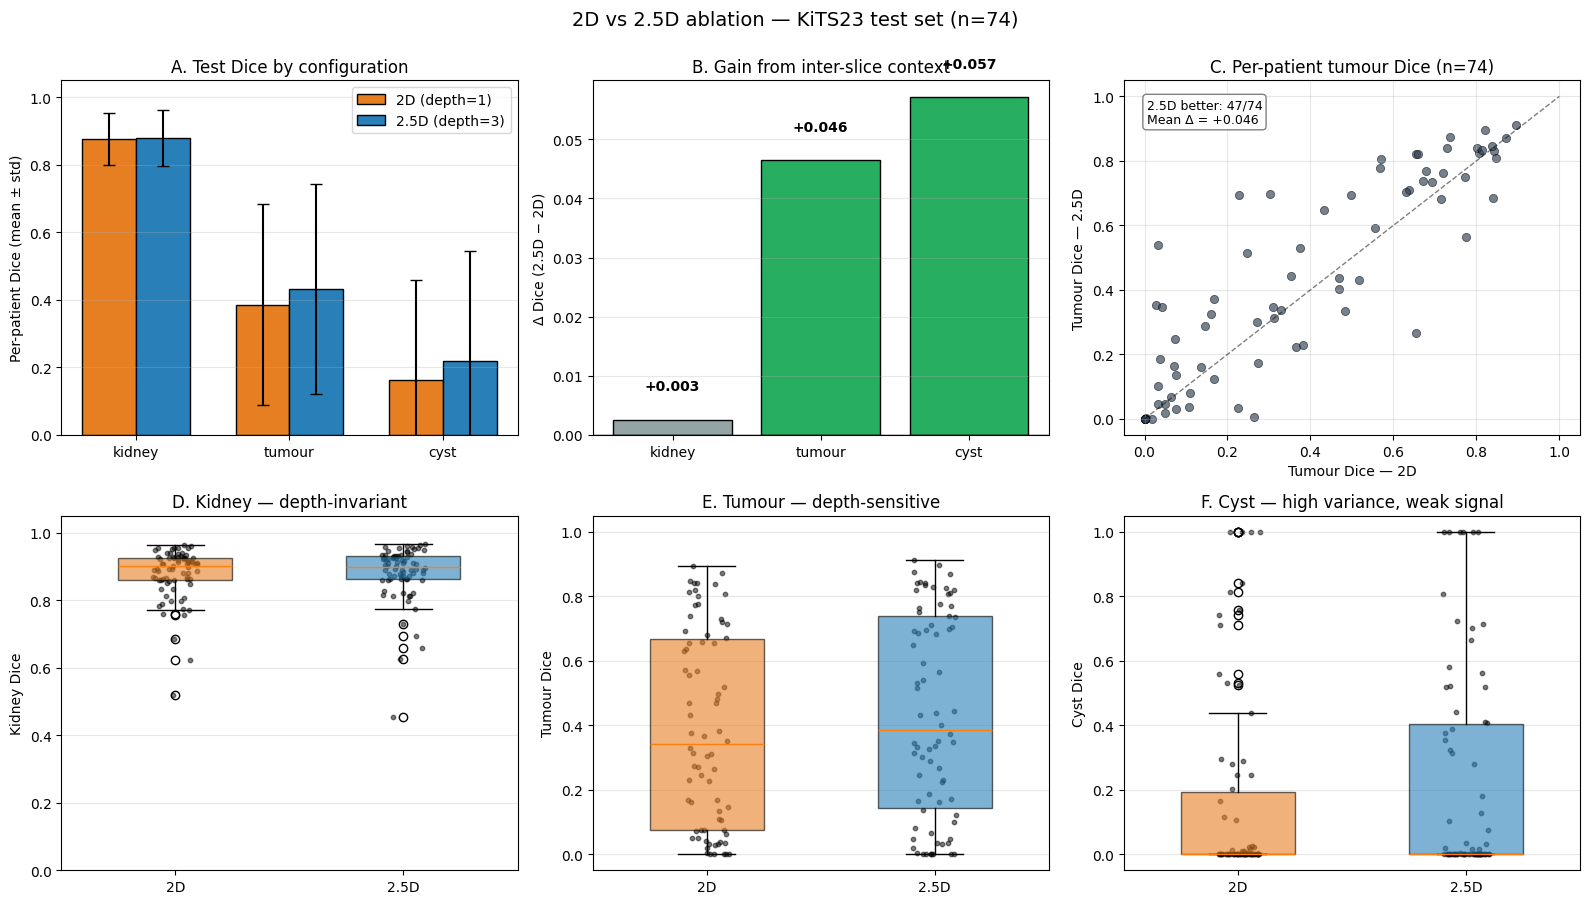

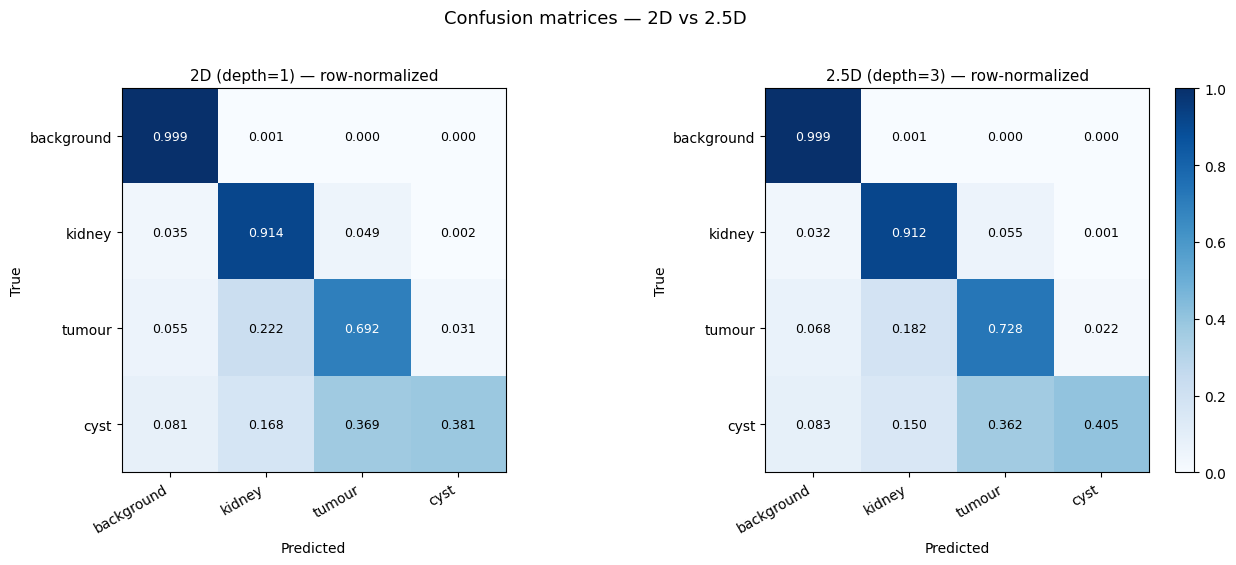

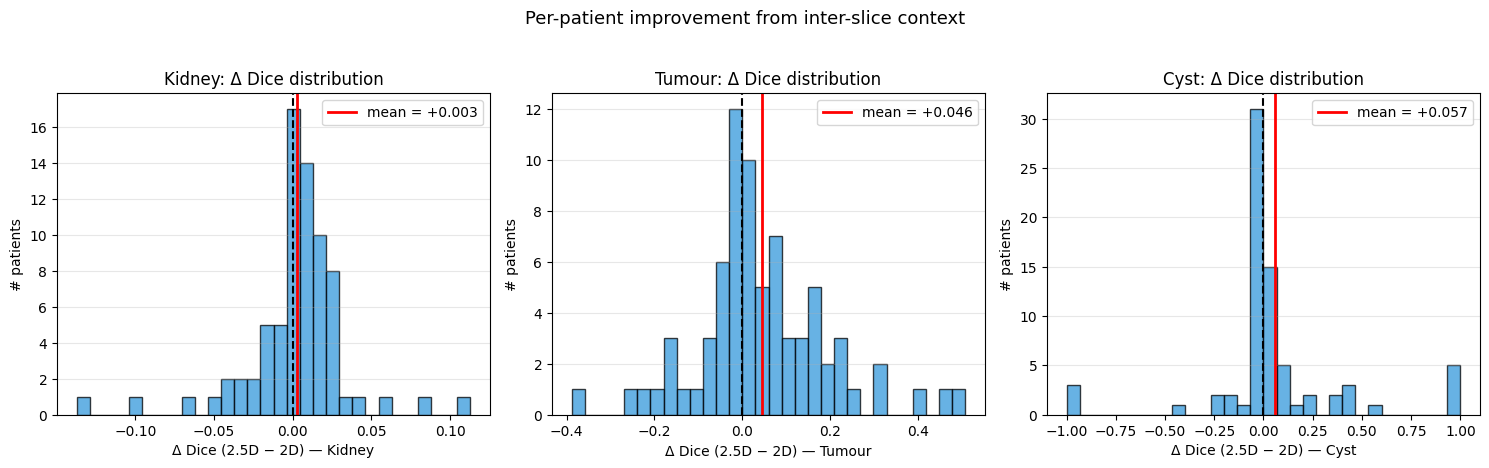


Saved:
  /content/drive/MyDrive/kits23_backup/ablations/fig10_ablation_dashboard.png
  /content/drive/MyDrive/kits23_backup/ablations/fig11_confusion_2d_vs_2p5d.png
  /content/drive/MyDrive/kits23_backup/ablations/fig12_delta_distributions.png
  /content/drive/MyDrive/kits23_backup/ablations/ablation_summary.csv
  /content/drive/MyDrive/kits23_backup/ablations/ablation_per_class.csv


In [60]:
# =========================================================
# CELL ABL1-C10 — 2D vs 2.5D ablation: FIGURES 10, 11, 12
# =========================================================
import pickle, csv
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
import itertools

ABL_ROOT = Path("/content/drive/MyDrive/kits23_backup/ablations")
MAIN_RESULTS = Path("/content/drive/MyDrive/kits23_backup/results")
MAIN_MODELS = Path("/content/drive/MyDrive/kits23_backup/models")

# ---------- 2D per-patient dice ----------
@torch.no_grad()
def per_patient_dice_generic(model, case_ids, num_classes=NUM_CLASSES, eps=1e-6):
    model.eval()
    results = {}
    for cid in tqdm(case_ids, desc="Dice"):
        img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
        D = img.shape[0]
        inter = np.zeros(num_classes); union = np.zeros(num_classes)
        chunk = 8
        for start in range(0, D, chunk):
            end = min(start + chunk, D)
            stacks, labels = [], []
            for i in range(start, end):
                half = SLICE_DEPTH // 2
                js = [min(max(i + d, 0), D - 1) for d in range(-half, half + 1)]
                stacks.append(np.stack([img[j] for j in js], axis=0))
                labels.append(seg[i])
            xb = torch.from_numpy(np.stack(stacks, 0).astype(np.float32)).to(device)
            yb = torch.from_numpy(np.stack(labels, 0).astype(np.int64)).to(device)
            preds = model(xb).argmax(1)
            for c in range(num_classes):
                p, t = (preds == c), (yb == c)
                inter[c] += (p & t).sum().item()
                union[c] += p.sum().item() + t.sum().item()
        results[cid] = {c: (2*inter[c]+eps)/(union[c]+eps) for c in range(num_classes)}
    return results


pp_2d = per_patient_dice_generic(model, test_ids)
print(f"2D per-patient Dice computed for {len(pp_2d)} patients")


# ---------- Reload 2.5D model ----------
model_2p5d = UNet2D(in_ch=3).to(device)
ckpt = torch.load(MAIN_MODELS / "unet2d_baseline.pth", map_location=device)
model_2p5d.load_state_dict(ckpt)
model_2p5d.eval()
print("2.5D model reloaded.")


# ---------- Evaluate 2.5D per-patient + confusion in one pass ----------
@torch.no_grad()
def per_patient_dice_and_confusion(model, case_ids, depth=3,
                                   num_classes=NUM_CLASSES, eps=1e-6):
    results = {}
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for cid in tqdm(case_ids, desc=f"2.5D eval"):
        img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
        D = img.shape[0]
        inter = np.zeros(num_classes); union = np.zeros(num_classes)
        chunk = 8
        half = depth // 2
        for start in range(0, D, chunk):
            end = min(start + chunk, D)
            stacks, labels = [], []
            for i in range(start, end):
                js = [min(max(i + d, 0), D - 1) for d in range(-half, half + 1)]
                stacks.append(np.stack([img[j] for j in js], axis=0))
                labels.append(seg[i])
            xb = torch.from_numpy(np.stack(stacks, 0).astype(np.float32)).to(device)
            yb = torch.from_numpy(np.stack(labels, 0).astype(np.int64)).to(device)
            preds = model(xb).argmax(1)
            for c in range(num_classes):
                p, t = (preds == c), (yb == c)
                inter[c] += (p & t).sum().item()
                union[c] += p.sum().item() + t.sum().item()
            yt = yb.cpu().numpy().ravel()
            yp = preds.cpu().numpy().ravel()
            cm += confusion_matrix(yt, yp, labels=list(range(num_classes)))
        results[cid] = {c: (2*inter[c]+eps)/(union[c]+eps) for c in range(num_classes)}
    return results, cm


pp_2p5d, cm_2p5d = per_patient_dice_and_confusion(model_2p5d, test_ids, depth=3)


# ---------- 2D confusion matrix ----------
@torch.no_grad()
def collect_confusion_generic(model, case_ids, depth, num_classes=NUM_CLASSES):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for cid in tqdm(case_ids, desc=f"CM depth={depth}"):
        img, seg = _load_npz_cached(str(CACHE_DIR / f"{cid}.npz"))
        D = img.shape[0]
        chunk = 8; half = depth // 2
        for start in range(0, D, chunk):
            end = min(start + chunk, D)
            stacks, labels = [], []
            for i in range(start, end):
                js = [min(max(i + d, 0), D - 1) for d in range(-half, half + 1)]
                stacks.append(np.stack([img[j] for j in js], axis=0))
                labels.append(seg[i])
            xb = torch.from_numpy(np.stack(stacks, 0).astype(np.float32)).to(device)
            yb = torch.from_numpy(np.stack(labels, 0).astype(np.int64)).to(device)
            preds = model(xb).argmax(1)
            yt = yb.cpu().numpy().ravel(); yp = preds.cpu().numpy().ravel()
            cm += confusion_matrix(yt, yp, labels=list(range(num_classes)))
    return cm


cm_2d = collect_confusion_generic(model, test_ids, depth=1)


# =========================================================
# FIGURE 10 — 2×3 ablation dashboard
# =========================================================
CLASS_COLORS_BAR = {"kidney": "#2ecc71", "tumour": "#e74c3c", "cyst": "#3498db"}
classes = ["kidney", "tumour", "cyst"]
class_idx = [1, 2, 3]

means_2d = [np.mean([pp_2d[c][i] for c in pp_2d]) for i in class_idx]
means_25 = [np.mean([pp_2p5d[c][i] for c in pp_2p5d]) for i in class_idx]
stds_2d  = [np.std([pp_2d[c][i] for c in pp_2d]) for i in class_idx]
stds_25  = [np.std([pp_2p5d[c][i] for c in pp_2p5d]) for i in class_idx]

fig = plt.figure(figsize=(16, 9))

# (A) Grouped bar with error bars
ax_a = fig.add_subplot(2, 3, 1)
x = np.arange(3); w = 0.35
ax_a.bar(x - w/2, means_2d, w, yerr=stds_2d, capsize=4,
         label="2D (depth=1)", color="#e67e22", edgecolor="black")
ax_a.bar(x + w/2, means_25, w, yerr=stds_25, capsize=4,
         label="2.5D (depth=3)", color="#2980b9", edgecolor="black")
ax_a.set_xticks(x); ax_a.set_xticklabels(classes)
ax_a.set_ylabel("Per-patient Dice (mean ± std)")
ax_a.set_title("A. Test Dice by configuration")
ax_a.set_ylim(0, 1.05); ax_a.grid(alpha=0.3, axis="y"); ax_a.legend()

# (B) Delta bars
ax_b = fig.add_subplot(2, 3, 2)
deltas = [m25 - m2d for m2d, m25 in zip(means_2d, means_25)]
colors = ["#27ae60" if d > 0.01 else "#95a5a6" if abs(d) < 0.01 else "#c0392b"
          for d in deltas]
ax_b.bar(classes, deltas, color=colors, edgecolor="black")
ax_b.axhline(0, color="black", lw=1)
ax_b.set_ylabel("Δ Dice (2.5D − 2D)")
ax_b.set_title("B. Gain from inter-slice context")
ax_b.grid(alpha=0.3, axis="y")
for i, d in enumerate(deltas):
    ax_b.text(i, d + (0.005 if d >= 0 else -0.010),
              f"{d:+.3f}", ha="center", fontweight="bold")

# (C) Tumour Dice scatter: 2D vs 2.5D
ax_c = fig.add_subplot(2, 3, 3)
common = sorted(set(pp_2d) & set(pp_2p5d))
x2d_t  = np.array([pp_2d[c][2]  for c in common])
x25d_t = np.array([pp_2p5d[c][2] for c in common])
ax_c.scatter(x2d_t, x25d_t, s=35, alpha=0.65, color="#2c3e50",
             edgecolor="black", lw=0.5)
ax_c.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax_c.set_xlabel("Tumour Dice — 2D")
ax_c.set_ylabel("Tumour Dice — 2.5D")
ax_c.set_title(f"C. Per-patient tumour Dice (n={len(common)})")
above = (x25d_t > x2d_t).sum()
ax_c.text(0.05, 0.95, f"2.5D better: {above}/{len(common)}\n"
                      f"Mean Δ = {(x25d_t-x2d_t).mean():+.3f}",
          transform=ax_c.transAxes, va="top", fontsize=9,
          bbox=dict(boxstyle="round", fc="white", ec="gray"))
ax_c.grid(alpha=0.3); ax_c.set_xlim(-0.05, 1.05); ax_c.set_ylim(-0.05, 1.05)

# (D) Paired box plots — kidney
ax_d = fig.add_subplot(2, 3, 4)
kid_2d  = [pp_2d[c][1]  for c in common]
kid_25d = [pp_2p5d[c][1] for c in common]
bp = ax_d.boxplot([kid_2d, kid_25d], labels=["2D", "2.5D"],
                   patch_artist=True, widths=0.5)
for patch, col in zip(bp['boxes'], ["#e67e22", "#2980b9"]):
    patch.set_facecolor(col); patch.set_alpha(0.6)
rng = np.random.default_rng(SEED)
for i, vals in enumerate([kid_2d, kid_25d], start=1):
    ax_d.scatter(np.full(len(vals), i) + rng.uniform(-0.1, 0.1, len(vals)),
                 vals, s=10, alpha=0.5, color="black")
ax_d.set_ylabel("Kidney Dice")
ax_d.set_title("D. Kidney — depth-invariant")
ax_d.grid(alpha=0.3, axis="y"); ax_d.set_ylim(0, 1.05)

# (E) Paired box plots — tumour
ax_e = fig.add_subplot(2, 3, 5)
tum_2d  = [pp_2d[c][2]  for c in common]
tum_25d = [pp_2p5d[c][2] for c in common]
bp = ax_e.boxplot([tum_2d, tum_25d], labels=["2D", "2.5D"],
                   patch_artist=True, widths=0.5)
for patch, col in zip(bp['boxes'], ["#e67e22", "#2980b9"]):
    patch.set_facecolor(col); patch.set_alpha(0.6)
for i, vals in enumerate([tum_2d, tum_25d], start=1):
    ax_e.scatter(np.full(len(vals), i) + rng.uniform(-0.1, 0.1, len(vals)),
                 vals, s=10, alpha=0.5, color="black")
ax_e.set_ylabel("Tumour Dice")
ax_e.set_title("E. Tumour — depth-sensitive")
ax_e.grid(alpha=0.3, axis="y"); ax_e.set_ylim(-0.05, 1.05)

# (F) Paired box plots — cyst
ax_f = fig.add_subplot(2, 3, 6)
cyst_2d  = [pp_2d[c][3]  for c in common]
cyst_25d = [pp_2p5d[c][3] for c in common]
bp = ax_f.boxplot([cyst_2d, cyst_25d], labels=["2D", "2.5D"],
                   patch_artist=True, widths=0.5)
for patch, col in zip(bp['boxes'], ["#e67e22", "#2980b9"]):
    patch.set_facecolor(col); patch.set_alpha(0.6)
for i, vals in enumerate([cyst_2d, cyst_25d], start=1):
    ax_f.scatter(np.full(len(vals), i) + rng.uniform(-0.1, 0.1, len(vals)),
                 vals, s=10, alpha=0.5, color="black")
ax_f.set_ylabel("Cyst Dice")
ax_f.set_title("F. Cyst — high variance, weak signal")
ax_f.grid(alpha=0.3, axis="y"); ax_f.set_ylim(-0.05, 1.05)

plt.suptitle("2D vs 2.5D ablation — KiTS23 test set (n=74)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(ABL_ROOT / "fig10_ablation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


# =========================================================
# FIGURE 11 — Confusion matrices (2D vs 2.5D, row-normalized)
# =========================================================
def plot_cm(ax, mat, title, cmap="Blues"):
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontsize=11)
    for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
        v = mat[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v > 0.5 else "black", fontsize=9)
    return im


cm_2d_n  = cm_2d  / cm_2d.sum(1,  keepdims=True).clip(min=1)
cm_25d_n = cm_2p5d / cm_2p5d.sum(1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
im0 = plot_cm(axes[0], cm_2d_n, "2D (depth=1) — row-normalized")
im1 = plot_cm(axes[1], cm_25d_n, "2.5D (depth=3) — row-normalized")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.suptitle("Confusion matrices — 2D vs 2.5D", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ABL_ROOT / "fig11_confusion_2d_vs_2p5d.png", dpi=150, bbox_inches="tight")
plt.show()


# =========================================================
# FIGURE 12 — Delta distribution per patient
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (idx, name) in zip(axes, [(1, "Kidney"), (2, "Tumour"), (3, "Cyst")]):
    deltas = np.array([pp_2p5d[c][idx] - pp_2d[c][idx] for c in common])
    ax.hist(deltas, bins=30, color="#3498db", edgecolor="black", alpha=0.75)
    ax.axvline(0, color="black", lw=1.5, ls="--")
    ax.axvline(deltas.mean(), color="red", lw=2,
               label=f"mean = {deltas.mean():+.3f}")
    ax.set_xlabel(f"Δ Dice (2.5D − 2D) — {name}")
    ax.set_ylabel("# patients")
    ax.set_title(f"{name}: Δ Dice distribution")
    ax.legend(); ax.grid(alpha=0.3, axis="y")

plt.suptitle("Per-patient improvement from inter-slice context",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(ABL_ROOT / "fig12_delta_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


# =========================================================
# Save everything
# =========================================================
with open(ABL_ROOT / "ablation_summary.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["config", "kidney", "tumour", "cyst"])
    w.writerow(["2D (depth=1)"]   + [f"{m:.4f}" for m in means_2d])
    w.writerow(["2.5D (depth=3)"] + [f"{m:.4f}" for m in means_25])
    w.writerow(["delta (2.5D-2D)"]+ [f"{d:+.4f}" for d in deltas])

# Per-class comparison table for thesis
with open(ABL_ROOT / "ablation_per_class.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["class", "2d_mean", "2d_std", "2p5d_mean", "2p5d_std", "delta"])
    for i, name in zip(class_idx, classes):
        w.writerow([name,
                    f"{means_2d[class_idx.index(i)]:.4f}",
                    f"{stds_2d[class_idx.index(i)]:.4f}",
                    f"{means_25[class_idx.index(i)]:.4f}",
                    f"{stds_25[class_idx.index(i)]:.4f}",
                    f"{deltas[class_idx.index(i)]:+.4f}"])

print(f"\nSaved:")
print(f"  {ABL_ROOT / 'fig10_ablation_dashboard.png'}")
print(f"  {ABL_ROOT / 'fig11_confusion_2d_vs_2p5d.png'}")
print(f"  {ABL_ROOT / 'fig12_delta_distributions.png'}")
print(f"  {ABL_ROOT / 'ablation_summary.csv'}")
print(f"  {ABL_ROOT / 'ablation_per_class.csv'}")

In [61]:
from google.colab import files
for f in ["fig10_ablation_dashboard.png",
          "fig11_confusion_2d_vs_2p5d.png",
          "fig12_delta_distributions.png",
          "ablation_summary.csv",
          "ablation_per_class.csv"]:
    files.download(str(ABL_ROOT / f))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
# =========================================================
# ARCHIVE VERIFICATION — confirm everything is on Drive
# =========================================================
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/kits23_backup")
print("=" * 60)
print("ARCHIVE VERIFICATION")
print("=" * 60)

checks = {
    "Model checkpoints": ROOT / "models",
    "Main results":       ROOT / "results",
    "Splits":             ROOT / "seg_splits",
    "Cache (npz)":        ROOT / "seg_cache",
    "Ablation 2D":        ROOT / "ablations" / "2d",
}

for label, p in checks.items():
    if p.exists():
        files = [f for f in p.rglob("*") if f.is_file()]
        n_files = len(files)
        size_mb = sum(f.stat().st_size for f in files) / 1e6
        print(f"✅ {label:22s} {n_files:5d} files  {size_mb:8.1f} MB  {p}")
    else:
        print(f"❌ {label:22s} MISSING  {p}")

ARCHIVE VERIFICATION
✅ Model checkpoints          2 files     124.4 MB  /content/drive/MyDrive/kits23_backup/models
✅ Main results              16 files   23746.6 MB  /content/drive/MyDrive/kits23_backup/results
✅ Splits                     3 files       0.0 MB  /content/drive/MyDrive/kits23_backup/seg_splits
✅ Cache (npz)              489 files    7667.5 MB  /content/drive/MyDrive/kits23_backup/seg_cache
✅ Ablation 2D                4 files      62.2 MB  /content/drive/MyDrive/kits23_backup/ablations/2d


In [64]:
from pathlib import Path
res = Path("/content/drive/MyDrive/kits23_backup/results")

print(f"{'file':40s} {'size (MB)':>12s}")
print("-" * 55)
for f in sorted(res.iterdir()):
    if f.is_file():
        size_mb = f.stat().st_size / 1e6
        print(f"{f.name:40s} {size_mb:>12.1f}")

file                                        size (MB)
-------------------------------------------------------
calibration_metrics.csv                           0.0
fig1_training_curves.png                          0.1
fig2_test_dice_ci.png                             0.0
fig3_per_patient_dist.png                         0.1
fig4_cyst_volume_vs_dice.png                      0.1
fig5_best_worst_cases.png                         0.5
fig6_confusion_matrix.png                         0.1
fig7_calibration.png                              0.1
fig8_uncertainty_heatmaps.png                     1.5
fig9_uncertainty_vs_error.png                     0.1
history.pkl                                       0.0
mc_dropout_results.pkl                        23744.0
per_class_metrics.csv                             0.0
per_patient_dice.pkl                              0.0
seg_examples.png                                  0.1
test_summary.csv                                  0.0


In [65]:
import pickle, numpy as np, gzip, os
from pathlib import Path

RES = Path("/content/drive/MyDrive/kits23_backup/results")
src = RES / "mc_dropout_results.pkl"
dst = RES / "mc_dropout_results_compact.pkl.gz"

print(f"Loading {src.stat().st_size / 1e9:.2f} GB...")
with open(src, "rb") as f:
    mc = pickle.load(f)

print(f"Loaded {len(mc)} patients. Downcasting...")

mc_compact = {}
for cid, d in mc.items():
    mc_compact[cid] = {
        "var_tumour": d["var_tumour"].astype(np.float16),
        "pred":       d["pred"].astype(np.uint8),
        "gt":         d["gt"].astype(np.uint8),
        "entropy":    d["entropy"].astype(np.float16),
    }

print(f"Writing compressed to {dst}...")
with gzip.open(dst, "wb", compresslevel=6) as f:
    pickle.dump(mc_compact, f, protocol=4)

# Report
orig_gb = src.stat().st_size / 1e9
new_gb = dst.stat().st_size / 1e9
print(f"\nOriginal:   {orig_gb:.2f} GB")
print(f"Compressed: {new_gb:.2f} GB")
print(f"Reduction:  {100 * (1 - new_gb/orig_gb):.1f}%")

# Sanity-check: reload and compare a random patient
with gzip.open(dst, "rb") as f:
    mc_check = pickle.load(f)
cid = list(mc_check.keys())[0]
print(f"\nRound-trip check on {cid}:")
print(f"  var_tumour dtype: {mc_check[cid]['var_tumour'].dtype}")
print(f"  var_tumour shape: {mc_check[cid]['var_tumour'].shape}")
print(f"  var max diff (float16 vs float64): "
      f"{np.abs(mc_check[cid]['var_tumour'].astype(np.float32) - mc[cid]['var_tumour']).max():.2e}")

Loading 23.74 GB...
Loaded 74 patients. Downcasting...
Writing compressed to /content/drive/MyDrive/kits23_backup/results/mc_dropout_results_compact.pkl.gz...

Original:   23.74 GB
Compressed: 4.72 GB
Reduction:  80.1%

Round-trip check on case_00212:
  var_tumour dtype: float16
  var_tumour shape: (512, 192, 192)
  var max diff (float16 vs float64): 6.10e-05


In [66]:
from pathlib import Path
src = Path("/content/drive/MyDrive/kits23_backup/results/mc_dropout_results.pkl")
src.unlink()
print(f"Deleted {src.name}")
print("Freed ~23.7 GB on Drive.")

Deleted mc_dropout_results.pkl
Freed ~23.7 GB on Drive.


In [67]:
from pathlib import Path
ROOT = Path("/content/drive/MyDrive/kits23_backup")
print("=" * 60)
print("ARCHIVE VERIFICATION (post-compression)")
print("=" * 60)

checks = {
    "Model checkpoints": ROOT / "models",
    "Main results":       ROOT / "results",
    "Splits":             ROOT / "seg_splits",
    "Cache (npz)":        ROOT / "seg_cache",
    "Ablation 2D":        ROOT / "ablations" / "2d",
}
total_gb = 0
for label, p in checks.items():
    if p.exists():
        files = [f for f in p.rglob("*") if f.is_file()]
        size_gb = sum(f.stat().st_size for f in files) / 1e9
        total_gb += size_gb
        print(f"✅ {label:22s} {len(files):5d} files  {size_gb:8.2f} GB")
    else:
        print(f"❌ {label:22s} MISSING")
print("-" * 60)
print(f"Total Drive usage: {total_gb:.2f} GB")

ARCHIVE VERIFICATION (post-compression)
✅ Model checkpoints          2 files      0.12 GB
✅ Main results              16 files      4.72 GB
✅ Splits                     3 files      0.00 GB
✅ Cache (npz)              489 files      7.67 GB
✅ Ablation 2D                4 files      0.06 GB
------------------------------------------------------------
Total Drive usage: 12.58 GB


In [68]:
import shutil
from pathlib import Path

SRC = Path("/content/drive/MyDrive/kits23_backup")
DST = Path("/content/drive/MyDrive/kits23_thesis_FINAL")

for sub in ["models", "results", "seg_splits", "ablations"]:
    s = SRC / sub
    d = DST / sub
    if s.exists():
        shutil.copytree(s, d, dirs_exist_ok=True)
        print(f"✅ Copied {sub}")

files = [f for f in DST.rglob("*") if f.is_file()]
size_gb = sum(f.stat().st_size for f in files) / 1e9
print(f"\nSecondary backup: {len(files)} files, {size_gb:.2f} GB")
print(f"Location: {DST}")

✅ Copied models
✅ Copied results
✅ Copied seg_splits
✅ Copied ablations

Secondary backup: 31 files, 4.91 GB
Location: /content/drive/MyDrive/kits23_thesis_FINAL


In [69]:
import shutil, os
from google.colab import files
from pathlib import Path

BUNDLE = Path("/content/thesis_results_bundle")
if BUNDLE.exists():
    shutil.rmtree(BUNDLE)
BUNDLE.mkdir()

SRC = Path("/content/drive/MyDrive/kits23_backup")
for sub in ["models", "results", "seg_splits", "ablations"]:
    s = SRC / sub
    if s.exists():
        shutil.copytree(s, BUNDLE / sub)

shutil.make_archive("/content/thesis_results_bundle", "zip", BUNDLE)
size_mb = os.path.getsize("/content/thesis_results_bundle.zip") / 1e6
print(f"Bundle: {size_mb:.1f} MB")
print("Starting browser download...")

files.download("/content/thesis_results_bundle.zip")

Bundle: 4895.8 MB
Starting browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>